### Measurement
Measurement begins with recording the ISSW-measured intensity of light when a filter paper contains LAI (for *light-absorbing impurity*), and $I_0$ when a filter is clean (see Eq. 1 of Grenfell et al, 2011, Eq. 1). Then the *absorption optical depth* is given by

$$
\chi_\lambda = log({I_0 \over I}) \ \ \ (1)
$$

where Here, we'll focus on $\lambda_1=450 \ nm$ and $\lambda_2=600 \ nm$). We can use the absorption optical depth to compute an *instrumental optical depth*, $\tau'_\lambda$, according to a version (the inverse) of Grenfell et al's Eq. 4,

$$
\tau'_\lambda = {1\over2}ln \bigl( (1-R_1R_2) \times exp(\chi_\lambda)+((1-R_1R_2)^2 \times exp(2\chi_\lambda)+4R_1R_2) \bigr) \ \ \ (2)
$$

where $R_1R_2=R_1R_2(\lambda)$ is the wavelength-dependent product of reflectivities of the two integrating spheres of the ISSW; other instrument-specific parameters are the size of the ISSW aperture and the intensity of the light source. Properties of the filter paper itself (e.g., nucleopore or millipore) also affect $\tau'_\lambda$. We account for these effects via a multiplicative factor $LRF$,

$$
\tau_\lambda  = {\tau'_\lambda \over LRF} \ \ \ (3)
$$

$LRF$ and $R_1R_2(\lambda)$ must be determined by a calibration procedure (described below). Once known, however, we can compute the LAI loading, 

$$
L_{ISSW} = {\tau_\lambda \over \beta_{\lambda,std}}  \ \ \ (4)
$$

where $\beta_{\lambda,std}$ is the *mass absorption cross section*, also referred to as *MAC*, of a standard LAI. For a fullerene standard, these values are $\beta_{450,fullerene}=8.9 \ m^2/g$ and $\beta_{600,fullerene}=6.5 \ m^2/g$, consistent with $Å=1.09$. For India ink standards, we use $\beta_{450,India}=5.0 \ m^2/g$ and $\beta_{600,India}=3.8 \ m^2/g$, consistent with $Å=0.92$. We can also use ratios of optical depths produced by Eq. 3 to calculate an LAI's's *absorption Angstrom exponent*,

$$
Å = -{log(\tau_{450}/\tau_{600}) \over log(\lambda_{450}/\lambda_{600})} \ \ \ (5)
$$

where (because of the proportionality in Eq. 3) we could also use $-{log(\tau'_{450}/\tau'_{600}) \over log(\lambda_{450}/\lambda_{600})}$ to achieve the same result.

### Calibration
The first goal of calibration is to obtain values of $R_1R_2(450 \ nm)$, $R_1R_2(600 \ nm)$, and $LRF$. The process begins with recording ISSW-measured intensities ($I$) of a set of filter papers with varying loadings ($L_{ISSW}$) of a standard LAI (fullerene or India ink). Equations 1-2 then allow us to compute a set of instrumental optical depths, designated $\tau'_{\lambda}(obs)$, but since prior to calibration we do not know the values of $R_1R_2(450)$ and $R_1R_2(600)$, Eq. 2 is repeated for a range of assumed values of those constants. We then use Eq. 4, with known values of the mass absorption cross section ($\beta_{\lambda,std}$) and loadings ($L_{ISSW}$), to compute a set of optical depths ($\tau_{\lambda}$). Those values are then used in Eq. 3 to obtain a set of instrumental optical depths, which we designate "$\tau'_\lambda$(theory)", but since prior to calibration we do not know the value of $LRF$, Eq. 3 is repeated for a range of assumed values. Optimal values of $R_1R_2(450)$, $R_1R_2(600)$, and $LRF$ are chosen as those that minimize the sum of squared differences between $\tau'_\lambda$(obs) and $\tau'_\lambda$(theory). 

A variant of this procedure is to minimize the sum of squared differences between $\chi'_\lambda$(obs) from Eq. 1, and $\chi'_\lambda$(theory) obtained from the foregoing values of $\tau'_\lambda$(theory) followed by the inverse of Eq. 2 (which is Grenfell et al's Eq. 4),

$$
\chi_\lambda = 2 \tau'_\lambda + ln \bigl ({1 - R_1R_2 e^{-4 \tau'_\lambda}   \over 1 - R_1R_2}    \bigr ) \ \ \ (6)
$$

Another calibration has to do with accounting for differences between ISSW measurements using nucleopore filters vs millipore filters. One approach would be to prepare a set of standard millipore filters of known loadings of a standard LAI, and repeat the process just described. Another option is to equate the ISSW-derived loading of a sample at a specified frequency ($450 \ nm$) to the LAHM-derived loading, 

$$
L_{LAHM} = L_{ISSW} \times \bigl ({L_{LAHM,std} \over L_{ISSW,std,450}} \bigr ) \ \ \ (7)
$$

Since the LAHM provides $L_{LAHM,std}$ for standard carbon black on millipore filter paper, a single measurement of the same filter on the ISSW yields $L_{ISSW,std,450}$, yielding the propotionality in parentheses on the right-hand side of Eq. 7. We should note that this procedure also takes into account a difference in units, namely, that $L_{ISSW}$ has units ${\mu g \over cm^2}$, while $L_{LAHM}$ has units $\mu g$.


**References**

Grenfell, T. C., Doherty, S. J., Clarke, A. D., & Warren, S. G. (2011). Light absorption from particulate impurities in snow and ice determined by spectrophotometric analysis of filters. Applied Optics, 50(14), 2037-2048.

Spinelli, L., Botwicz, M., Zolek, N., Kacprzak, M., Milej, D., Sawosz, P., ... & Zaccanti, G. (2014). Determination of reference values for optical properties of liquid phantoms based on Intralipid and India ink. Biomedical optics express, 5(7), 2037-2053.

In [1]:
import numpy as np
import ISSWlib as IS
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

### Specifying the input parameters for standards

### India ink
AAE of India ink was adjusted to get good results for the AAE of nucleopore fullerene samples (which is 1.09). The MAC ("beta1_std") is based on Spinelli et al 2021, extrapolated to 450 nm from 384, 324, 290 nm, using an assumed density of 1 g/cm^2, and a concentration of 10% by weight, which is in the midrange described by the patent at https://patents.google.com/patent/JPH06234946A/en, rounded to the nearest integer value because the recommended range is quite big (8-12%).

The % accuracy of the retrievals of these same samples is good only for the last three loadings (6.34, 11.8, and 25.4 ug/cm^2).

In [2]:
spectrum_folder = 'UPS_INKStandards/'
spectrum_filelist = spectrum_folder+'spectrum_files.txt'
spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

# MACs for this standard
beta1_std = 5 # This is in m^2/g, for 450 
AAE_std = 0.92; print('AAE from betas = ', AAE_std)
beta2_std = beta1_std * (450/600)**AAE_std; print('beta2_std from AAE = ', beta2_std)

# Setting up a range of R1R2
R1R2_range = np.linspace(0.4,.95,300)

# Setting up a range of filter factors
LRF_range = np.linspace(0.1, 0.50, 100)

# Lay out a set of loading values
L_range = np.array([0.55, 0.86, 3.02, 6.34, 11.8, 25.4]) # This is in microgram/cm^2

# Parameter file
parameter_filename = 'calibration parameters from UPS_INKStandards (July 13, 2026).csv'
Save_parameter_file = False

From getline0list: In  UPS_INKStandards/spectrum_files.txt , finding these spectra:
      B.10mL.txt
      A.14mL.txt
      C.20mL.txt
      C.34mL.txt
      C.50mL.txt
      C.57mL.txt
AAE from betas =  0.92
beta2_std from AAE =  3.837305416303432


In [3]:
# spectrum_folder = '2026July7/NucInk/'
# spectrum_filelist = spectrum_folder+'spectrum_files.txt'
# spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

# # MACs for this standard
# beta1_std = 5 # This is in m^2/g, for 450 
# AAE_std = 0.92; print('AAE from betas = ', AAE_std)
# beta2_std = beta1_std * (450/600)**AAE_std; print('beta2_std from AAE = ', beta2_std)

# # Setting up a range of R1R2
# R1R2_range = np.linspace(0.15,.95,300)

# # Setting up a range of filter factors
# LRF_range = np.linspace(0.1, 0.60, 100)

# # Lay out a set of loading values
# L_range = np.array([1.37, 1.94, 3.02, 4.01, 4.80, 6.34, 8.12, 11.8]) # This is in microgram/cm^2

# # Output Parameter file
# parameter_filename = 'calibration parameters (July 7, 2026).csv'

In [4]:
# spectrum_folder = '2026July7/NucInk/'
# spectrum_filelist = spectrum_folder+'spectrum_files_complete.txt'
# spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

# # MACs for this standard
# beta1_std = 5 # This is in m^2/g, for 450 
# AAE_std = 0.92; print('AAE from betas = ', AAE_std)
# beta2_std = beta1_std * (450/600)**AAE_std; print('beta2_std from AAE = ', beta2_std)

# # Setting up a range of R1R2
# R1R2_range = np.linspace(0.15,.95,300)

# # Setting up a range of filter factors
# LRF_range = np.linspace(0.1, 0.60, 100)

# # Lay out a set of loading values
# L_range = np.array([0.43, 0.31, 0.55, 0.75, 0.86, 1.37, 1.94, 3.02, 4.01, 4.80, 6.34, 8.12, 11.8]) # This is in microgram/cm^2

# # Output Parameter file
# parameter_filename = 'calibration parameters (July 7, 2026).csv'

### Fullerene standard
The AAE are standard values that Sarah D. quotes in various papers.

In [5]:
# spectrum_folder = 'NuCStandards/'
# spectrum_filelist = spectrum_folder+'spectrum_files.txt'
# spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

# # MACs
# beta1 = 8.9 # This is in m^2/g, for 450
# AAE_std = 1.09; print('AAE from betas = ', AAE_std)
# beta2 = beta1 * (450/600)**AAE_std; print('beta2 from AAE = ', beta2)

# # Setting up a range of R1R2
# R1R2_range = np.linspace(0.5,.85,500)

# # Setting up a range of filter factors
# LRF_range = np.linspace(0.15, 0.232, 15)

# # Lay out a set of loading values (have to copy these down)
# L_range = np.array([...]) # This is in microgram/cm^2

# # Parameter file
# parameter_filename = 'calibration parameters.csv'

In [6]:
# spectrum_folder = '2026July7/NucFul/'
# spectrum_filelist = spectrum_folder+'spectrum_files.txt'
# spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

# # MACs for this standard
# beta1_std = 8.9 # This is in m^2/g, for 450 
# AAE_std = 1.09; print('AAE from betas = ', AAE_std)
# beta2_std = beta1_std * (450/600)**AAE_std; print('beta2_std from AAE = ', beta2_std)

# # Setting up a range of R1R2
# R1R2_range = np.linspace(0.15,.95,300)

# # Setting up a range of filter factors
# LRF_range = np.linspace(0.1, 0.60, 100)

# # Lay out a set of loading values
# L_range = np.array([0.86, 1.03, 1.81]) # This is in microgram/cm^2 ... leaving out 4 

# # Output Parameter file
# parameter_filename = 'calibration parameters from 2026July7 NucFul (July 13, 2026).csv'
# Save_parameter_file = False

In [7]:
# spectrum_folder = '2026July7/NucFul/'
# spectrum_filelist = spectrum_folder+'spectrum_files.txt'
# spectrum_list, number_of_loadings = IS.get_spectrum_list(spectrum_filelist)

# # MACs for this standard
# beta1_std = 8.9 # This is in m^2/g, for 450 
# AAE_std = 1.09; print('AAE from betas = ', AAE_std)
# beta2_std = beta1_std * (450/600)**AAE_std; print('beta2_std from AAE = ', beta2_std)

# # Setting up a range of R1R2
# R1R2_range = np.linspace(0.15,.95,300)

# # Setting up a range of filter factors
# LRF_range = np.linspace(0.1, 0.60, 100)

# # Lay out a set of loading values
# L_range = np.array([0.75, 0.86, 1.03, 1.81]) # This is in microgram/cm^2

# # Output Parameter file
# parameter_filename = 'calibration parameters from 2026July7 NucFul (July 13, 2026).csv'
# Save_parameter_file = False

In [8]:
# Double-checking
print('Length of L_range = ', len(L_range))
print('Number of loadings = ', number_of_loadings)

if len(L_range) != number_of_loadings:
    print('inconsistency')
    np.sqrt(-1)

Length of L_range =  6
Number of loadings =  6


In [9]:
# Additional multiplier to enforce ISSW/LAHM agreement for a "Fullerene" sample on LAHM filter paper
LAHM_factor = 8.8/19.0 # based on UPS_Rainier2025-07-03-01/1A.txt

In [10]:
# Load in the blank, and check indices
lambda_nm, I0_raw = IS.get_spectrum(spectrum_folder+'/Blank.txt')
I_450 = 100; print('lambda_450 = ',lambda_nm[I_450])
I_600 = 250; print('lambda_600 = ',lambda_nm[I_600])
I_1 = I_450
I_2 = I_600

# Report the AAE for this standard
print('AAE for this standard = ',-np.log(beta1_std/beta2_std)/np.log(lambda_nm[I_1]/lambda_nm[I_2]))

lambda_450 =  450.0
lambda_600 =  600.0
AAE for this standard =  0.9199999999999996


In [11]:
# Preallocate arrays
chi_observed = np.zeros((number_of_loadings,2))

[[0.10675694 0.07533085]
 [0.13786454 0.10553502]
 [0.35274588 0.31159369]
 [0.61801001 0.57764665]
 [0.96510315 0.91957422]
 [1.68372798 1.55170354]]


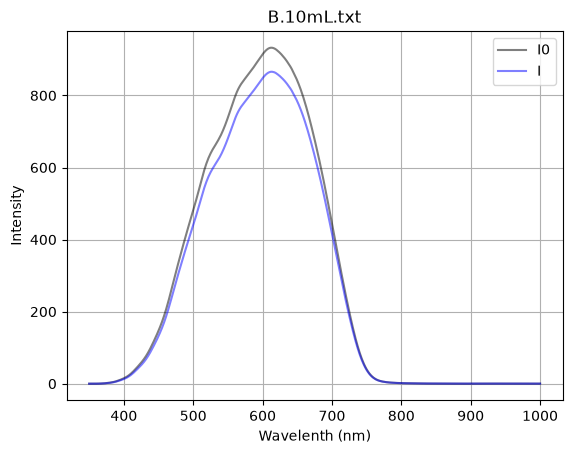

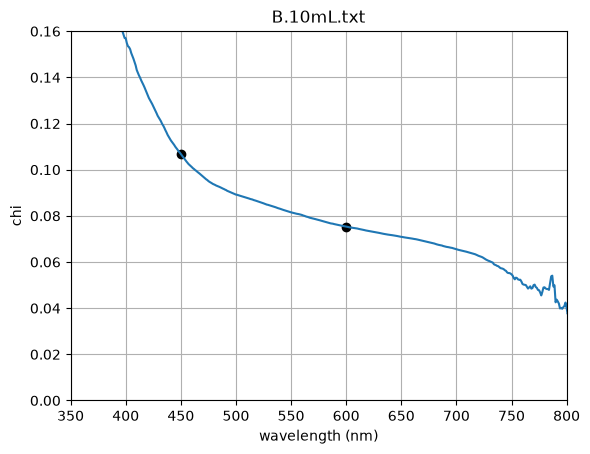

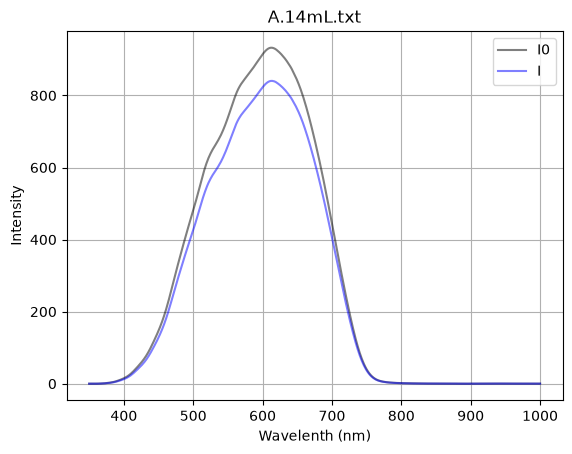

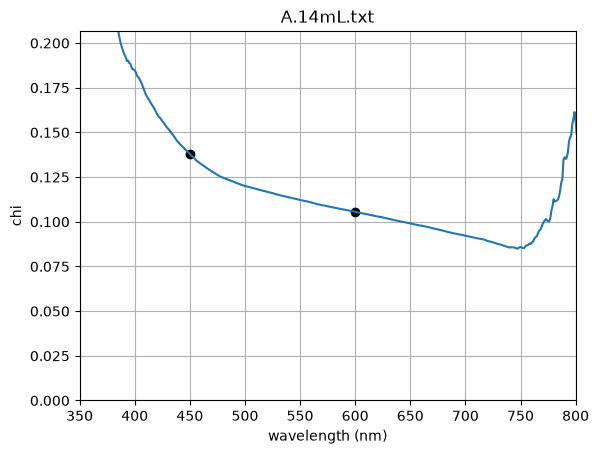

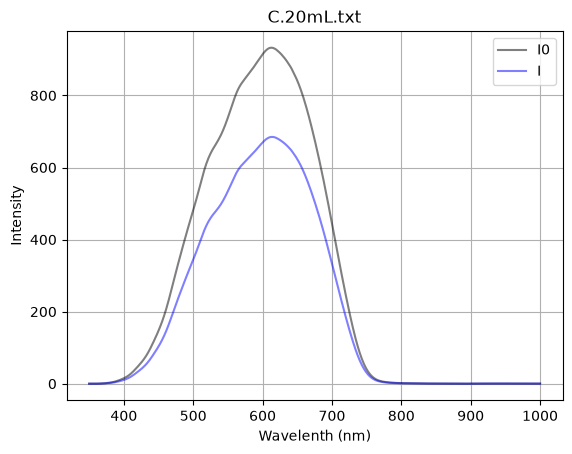

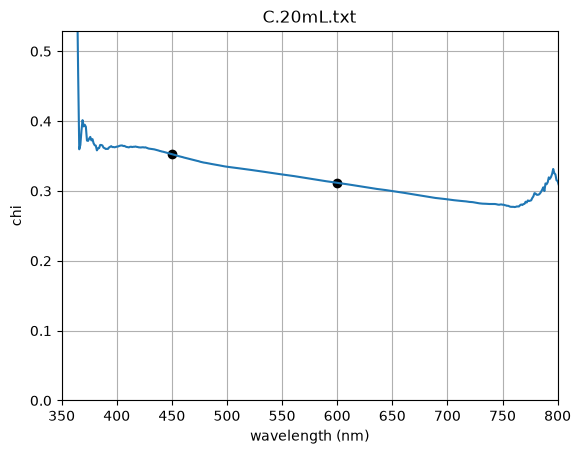

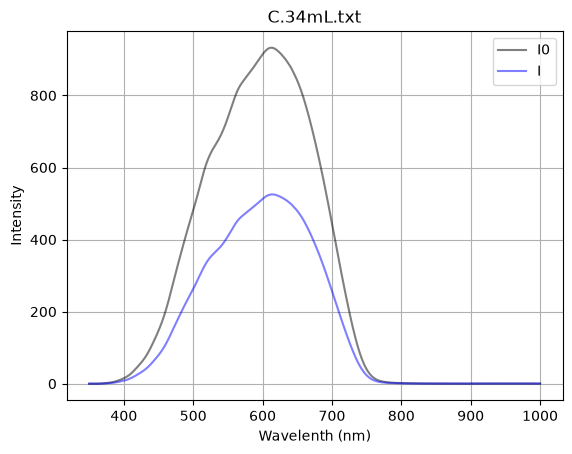

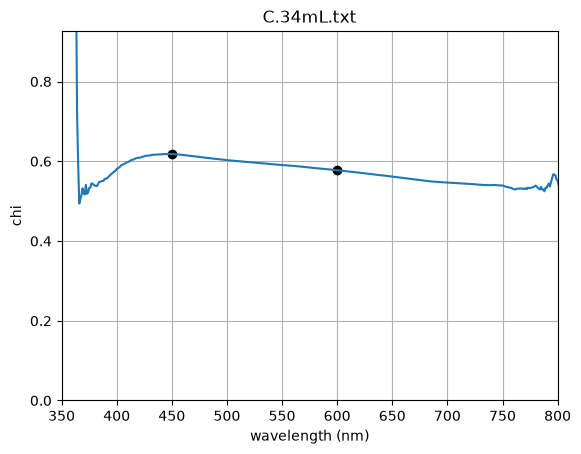

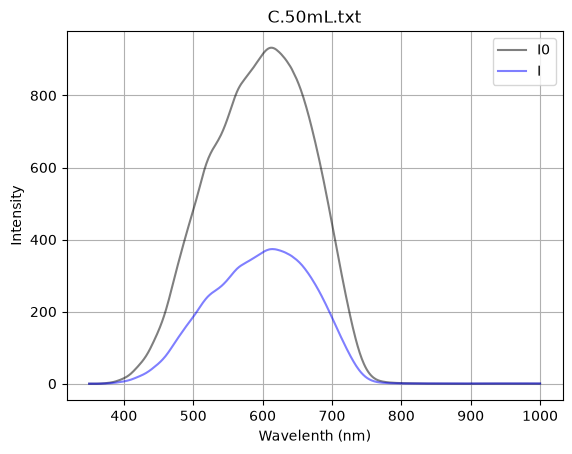

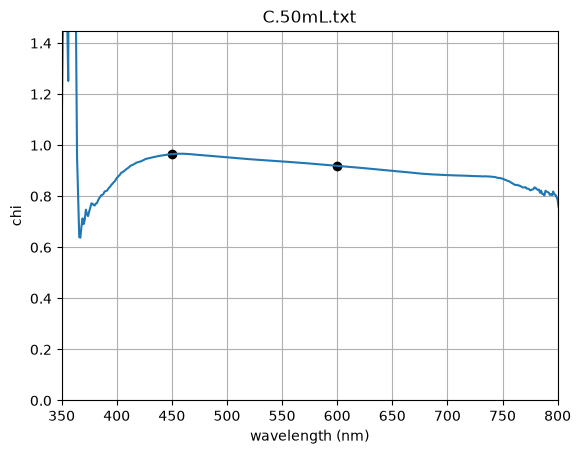

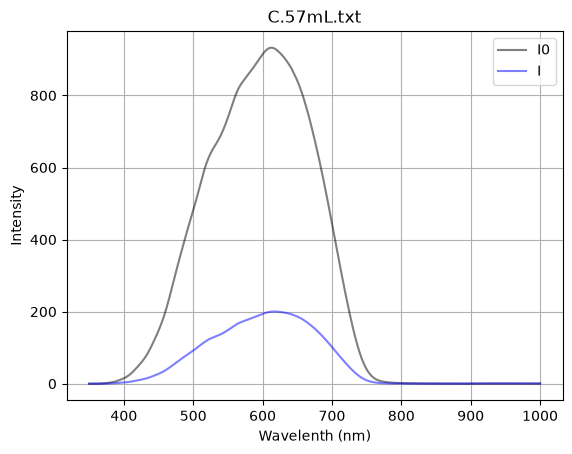

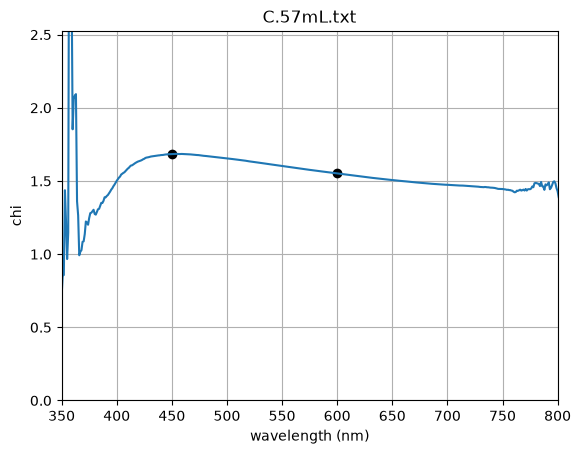

In [12]:
# Get the chi-values
for i in range(number_of_loadings):
    
    # Extract the spectrum for this item in the list
    spectrum_filename = spectrum_list[i]
    lambda_nm, I_raw = IS.get_spectrum(spectrum_folder+spectrum_filename)
    
    # Smooth and shift
    I, I0 = IS.smooth_and_shift(I_raw,I0_raw)
    
    # Get observed chi
    chi = IS.get_chi_obs(I,I0,lambda_nm, title=spectrum_filename)
    
    # Save chi values at lambda1 and lambda2
    chi_observed[i,0] = chi[I_1]
    chi_observed[i,1] = chi[I_2]

print(chi_observed)

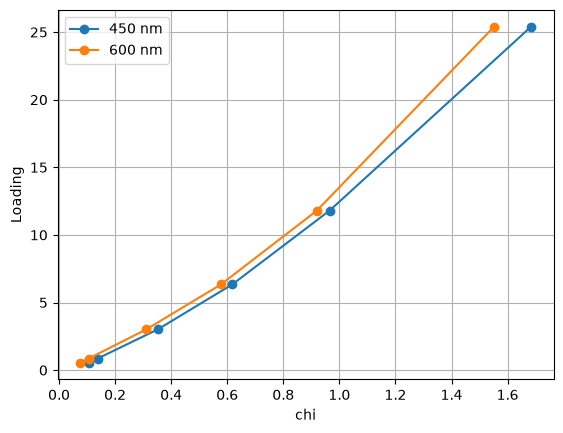

In [13]:
# Let's take a look
plt.figure()
plt.plot(chi_observed[:,0],L_range,marker='o',label='450 nm')
plt.plot(chi_observed[:,1],L_range,marker='o',label='600 nm')
plt.legend()
plt.xlabel('chi')
plt.ylabel('Loading')
plt.grid(True)

### Using Tom's theory
The cell below uses Tom's formulas. There's some guesswork on the ranges of R1R2 and LRF, so the plots should be inspected to be sure that the minima and maxima are not at the extremes of those ranges.

/home/chemistry/LAI_in_snow/ISSW/ISSWlib.py:256: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


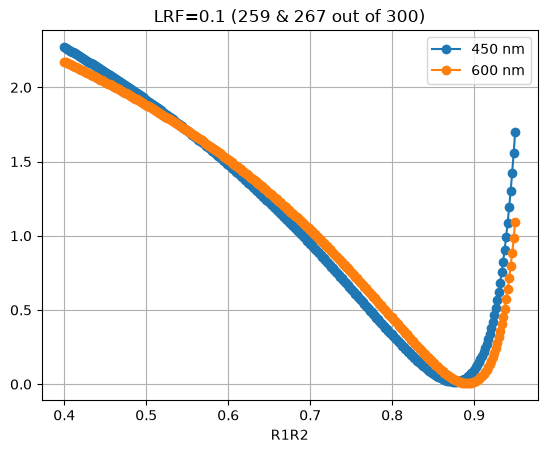

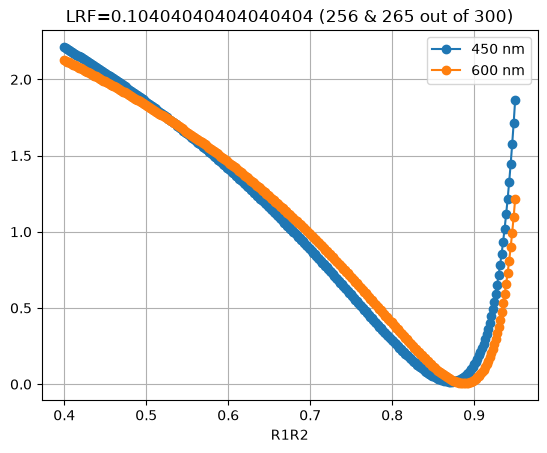

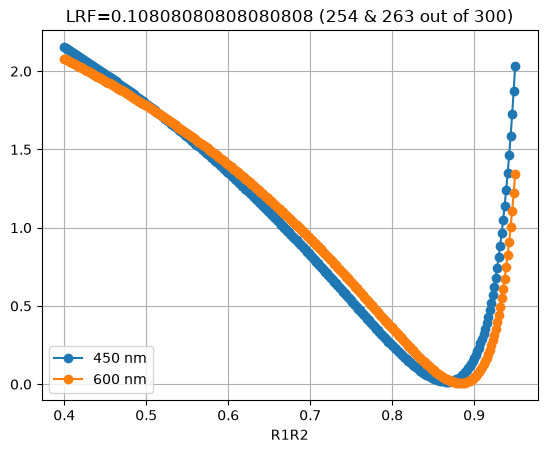

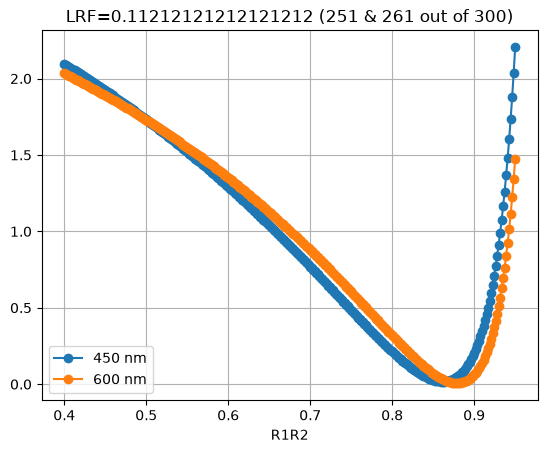

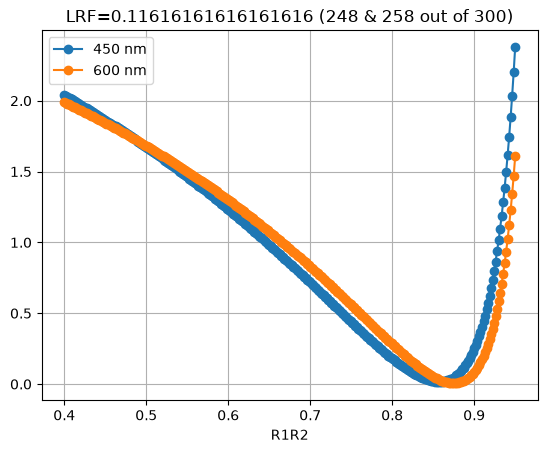

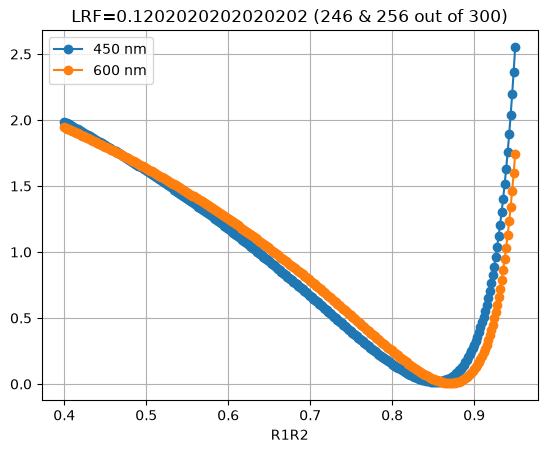

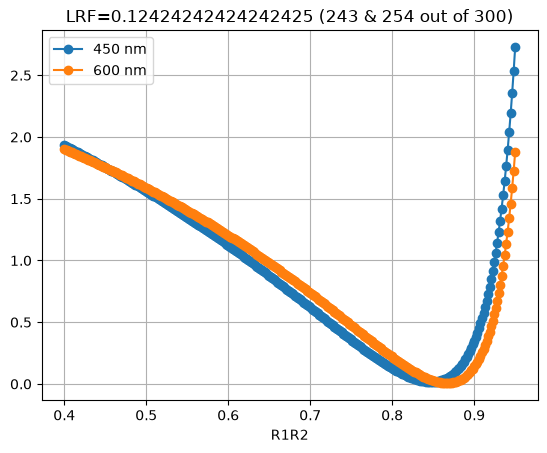

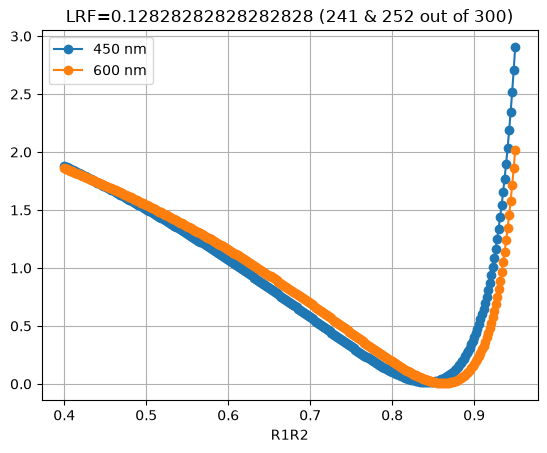

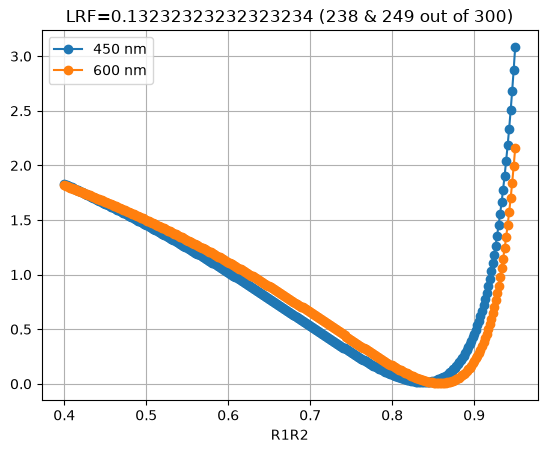

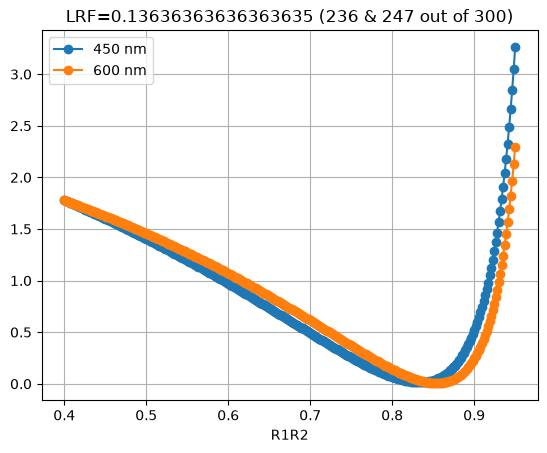

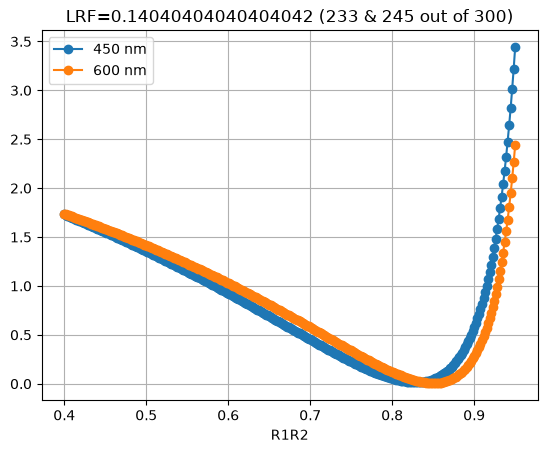

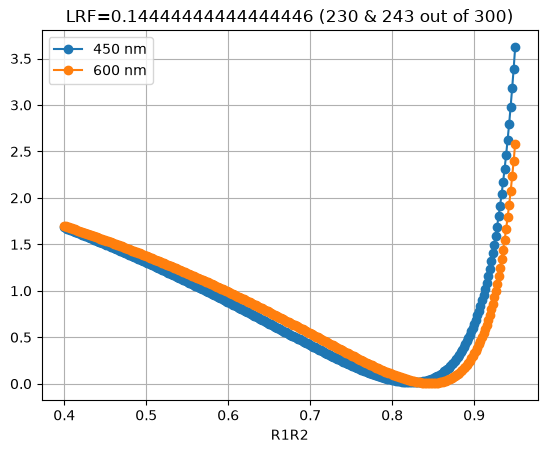

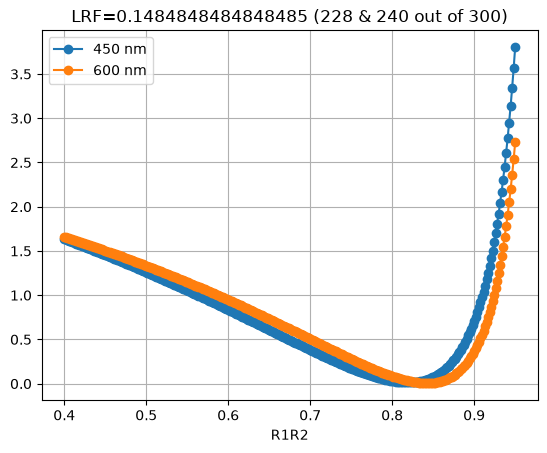

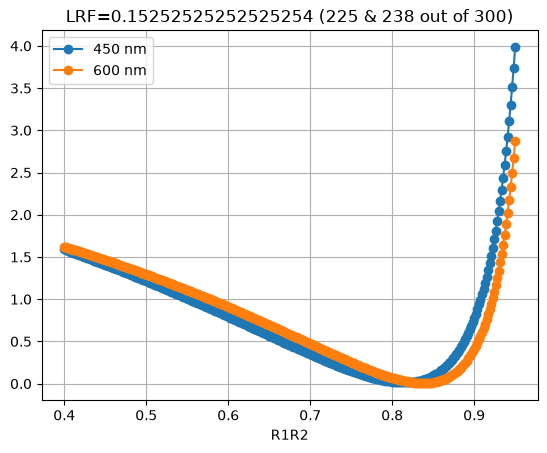

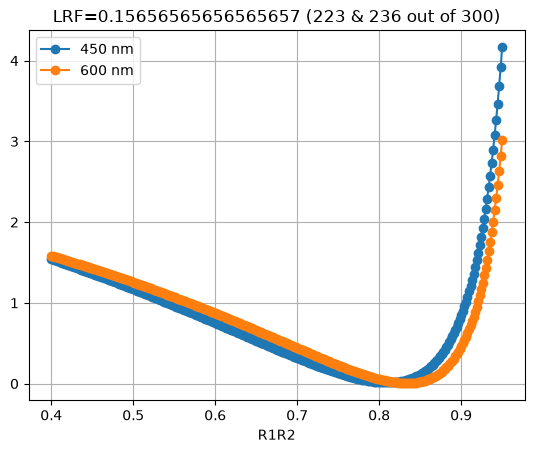

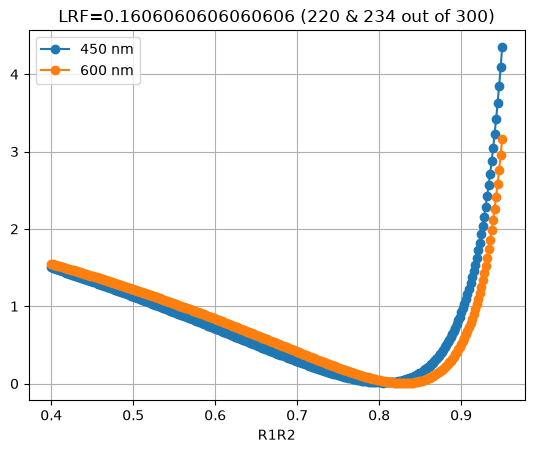

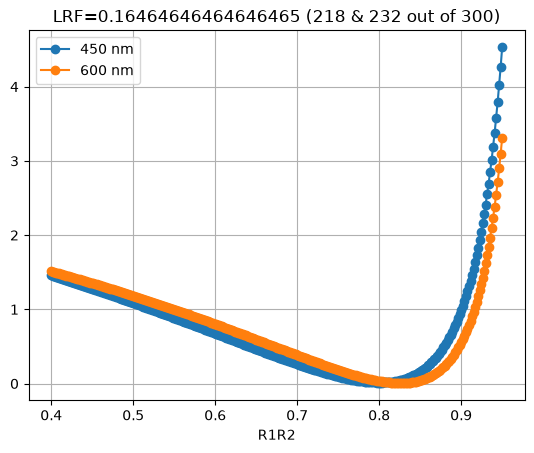

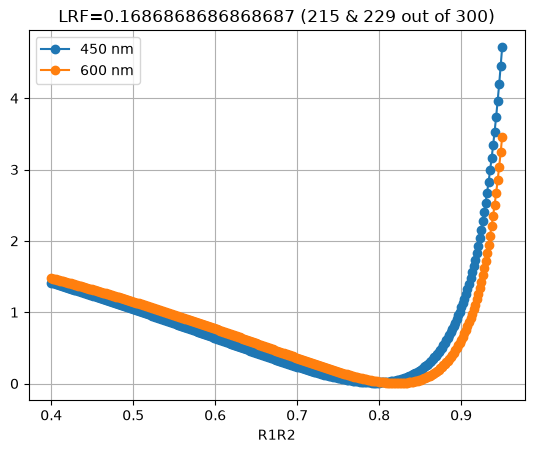

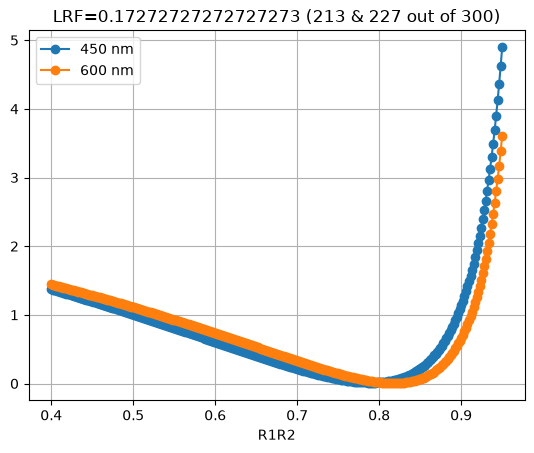

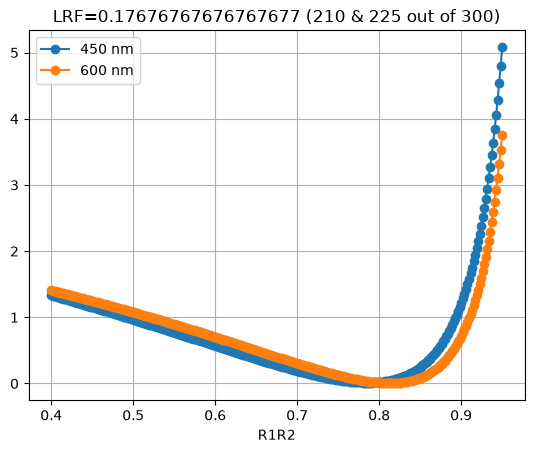

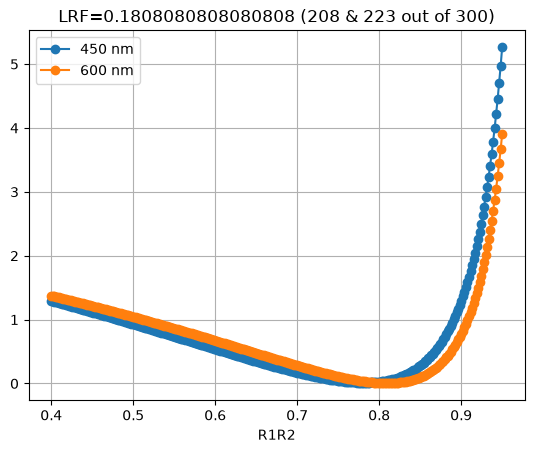

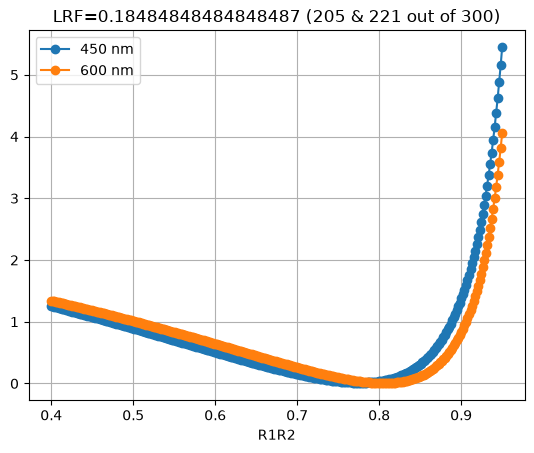

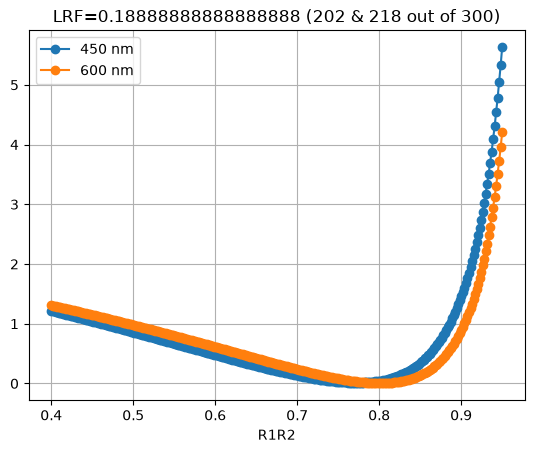

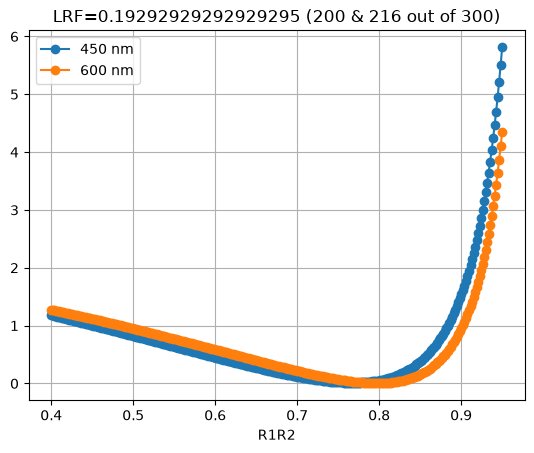

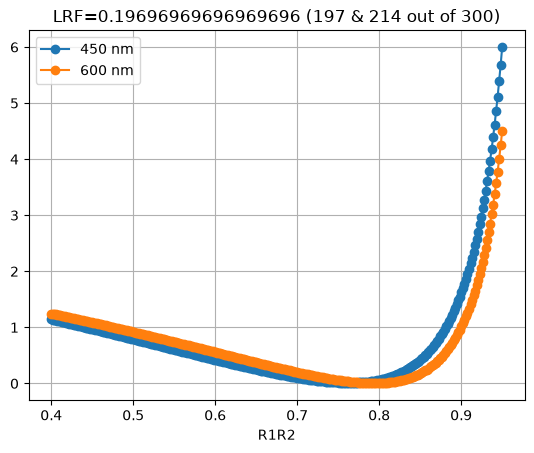

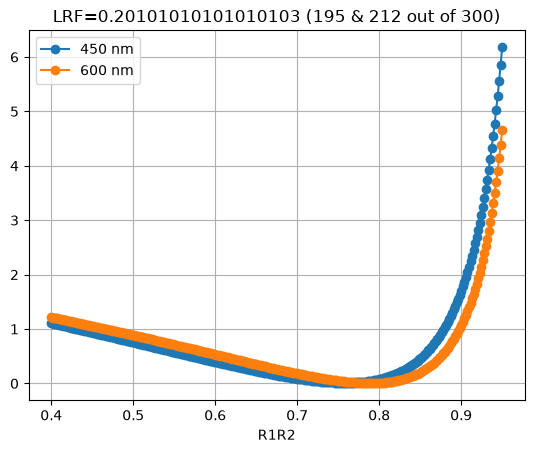

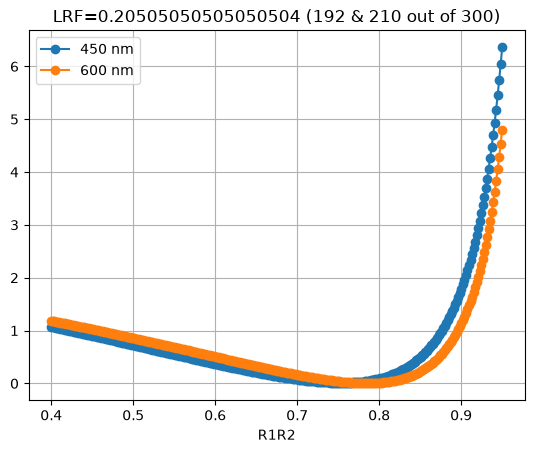

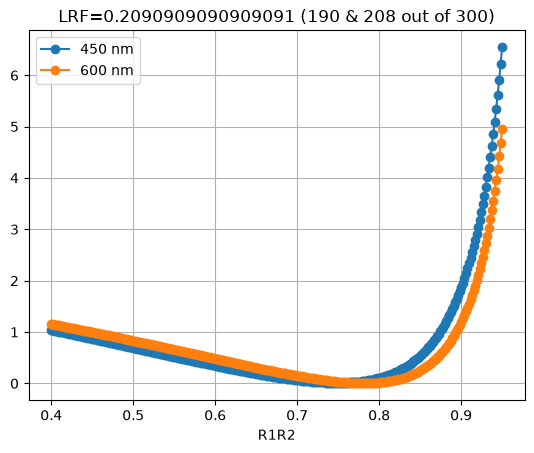

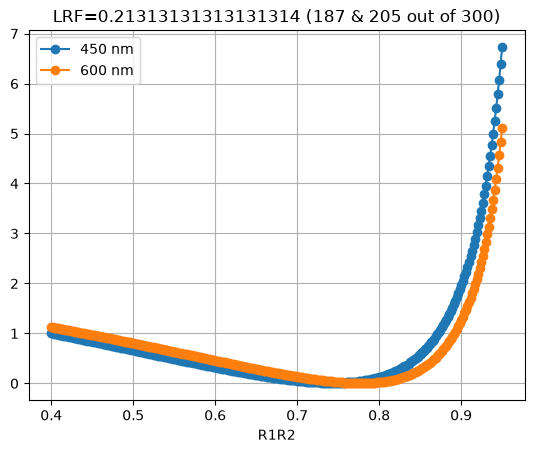

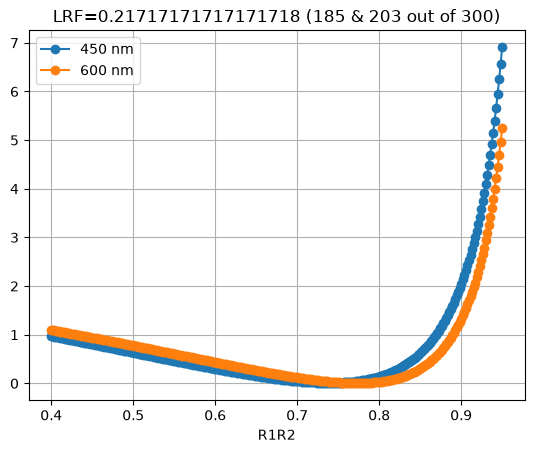

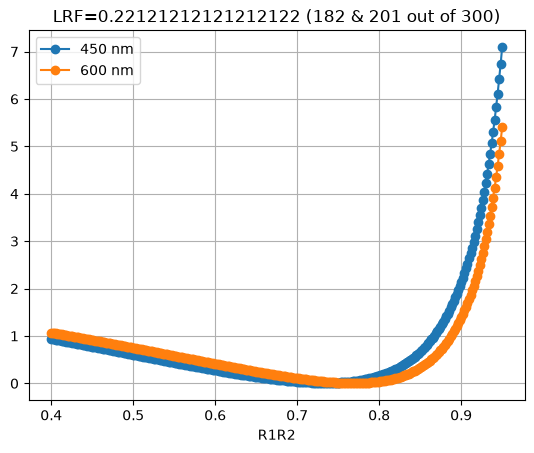

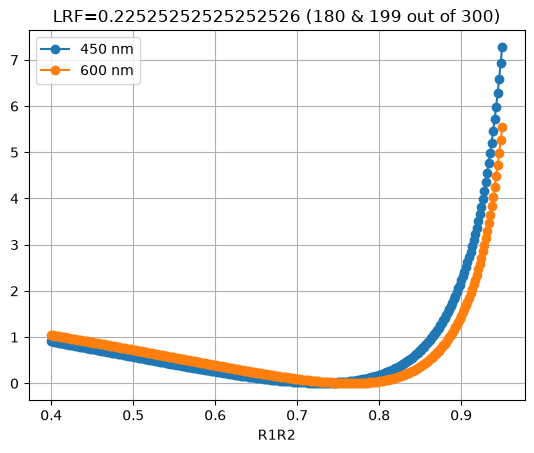

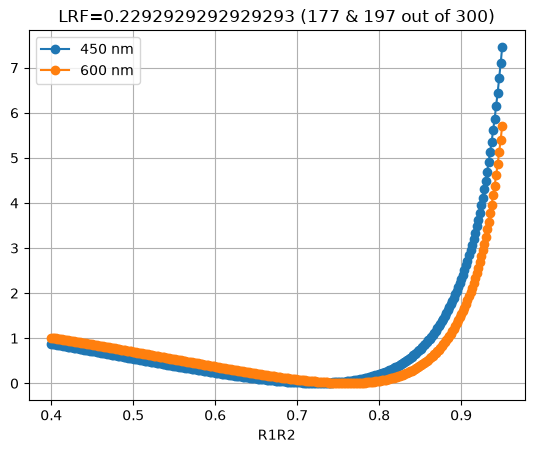

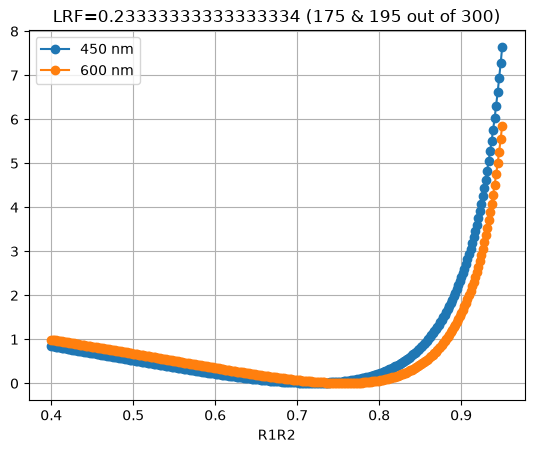

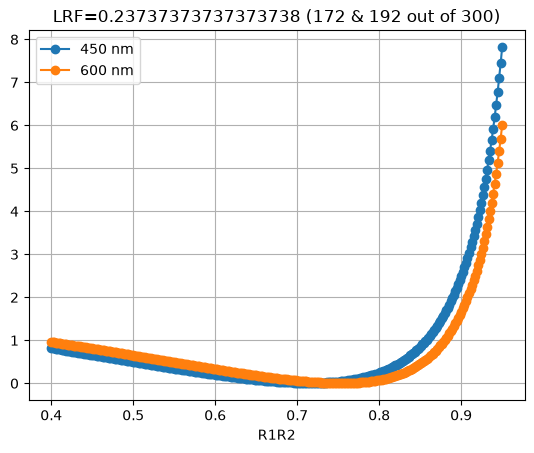

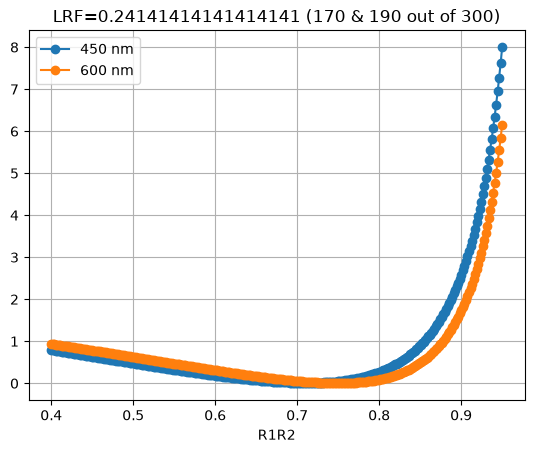

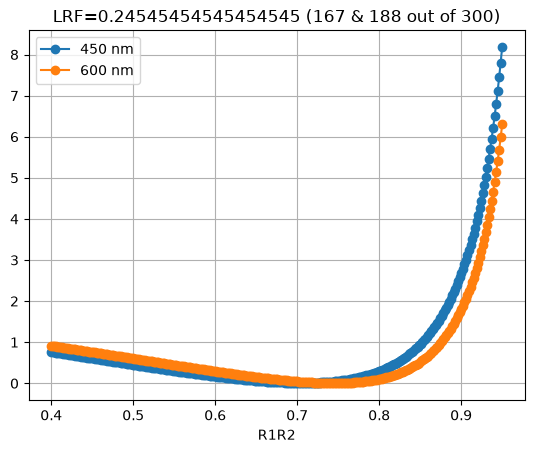

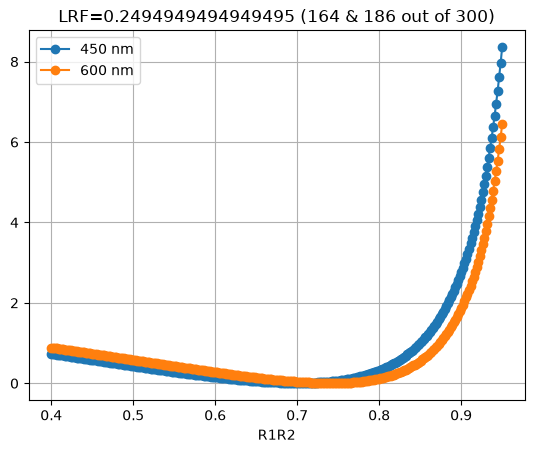

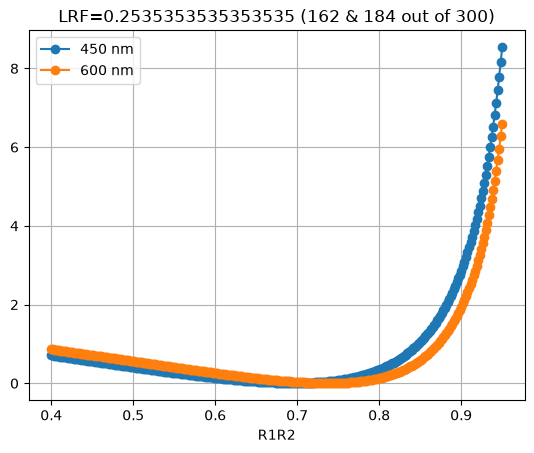

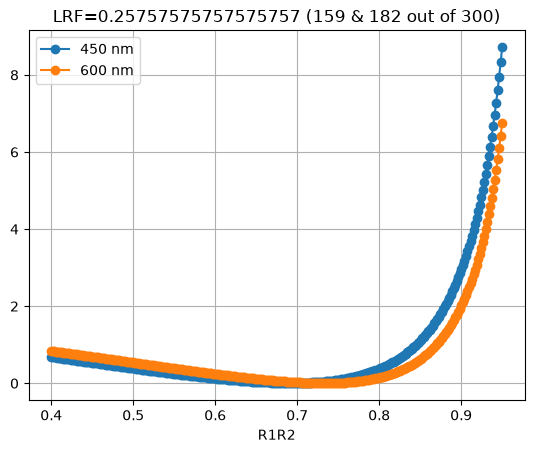

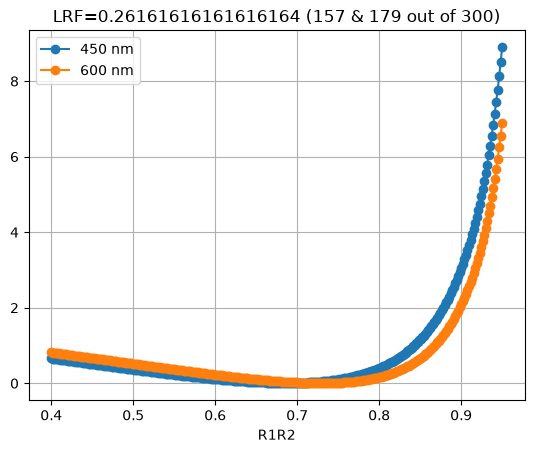

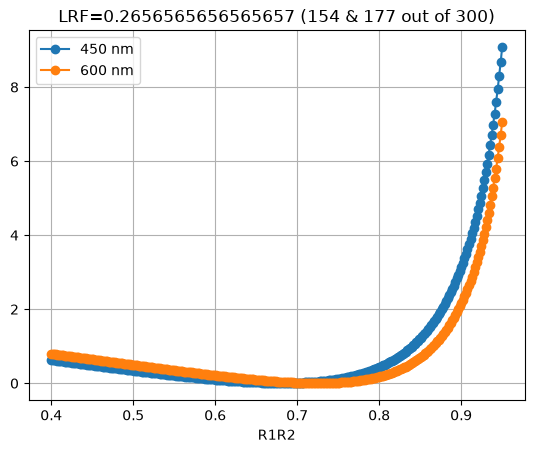

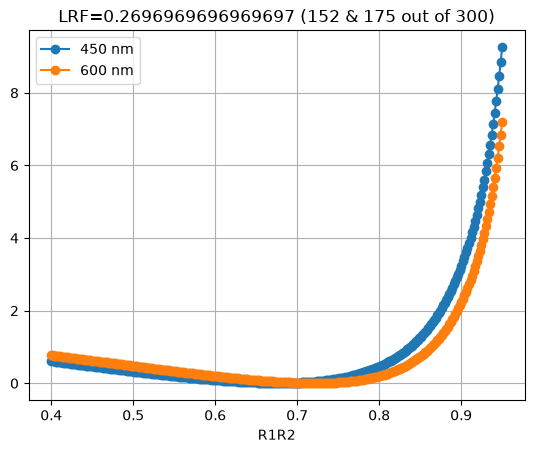

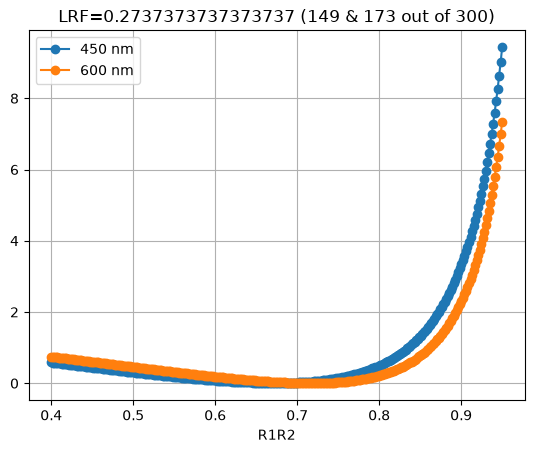

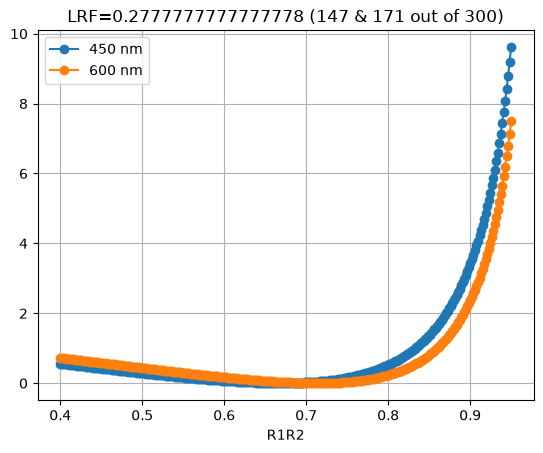

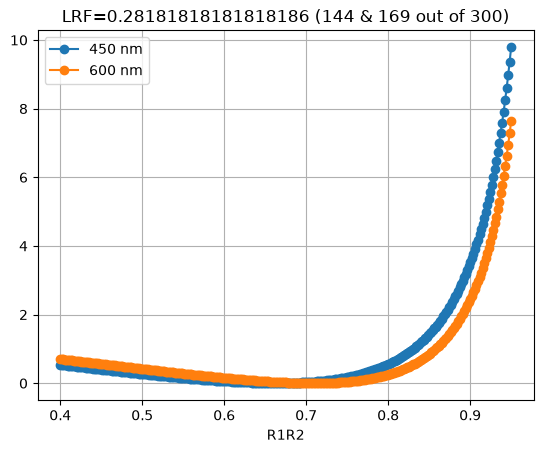

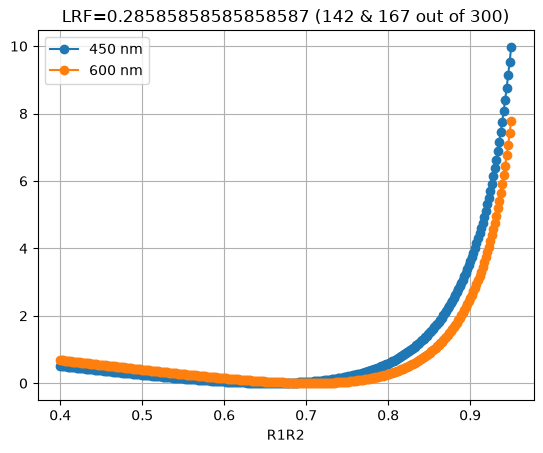

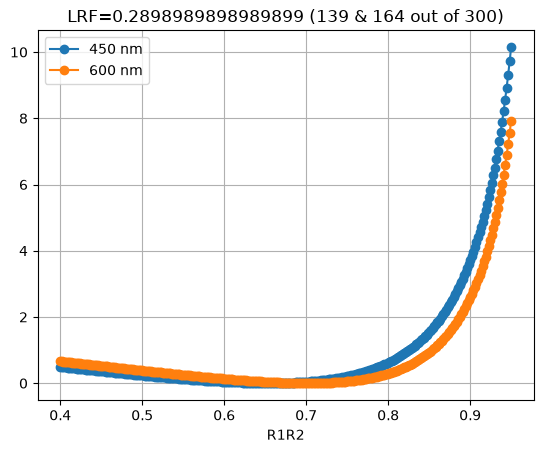

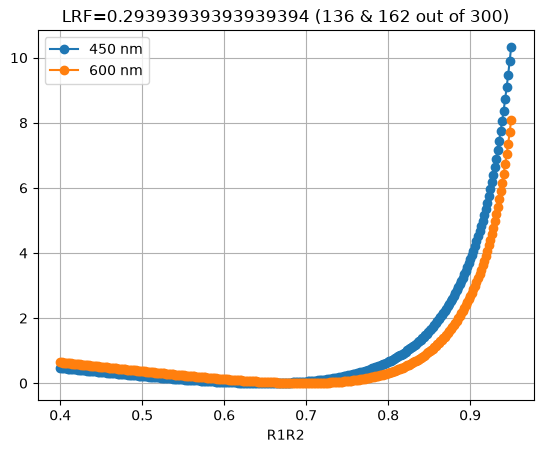

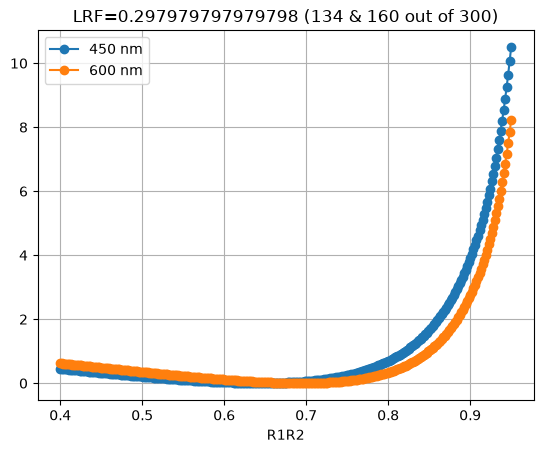

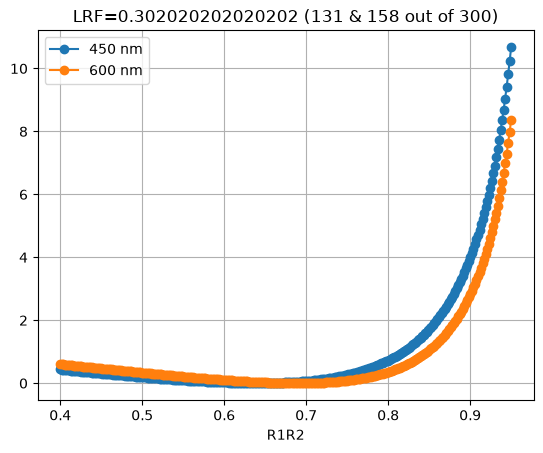

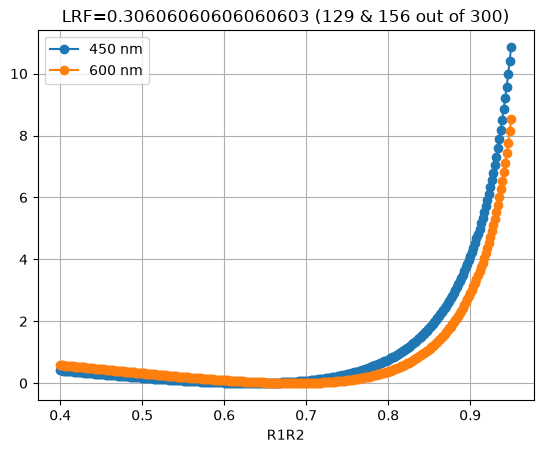

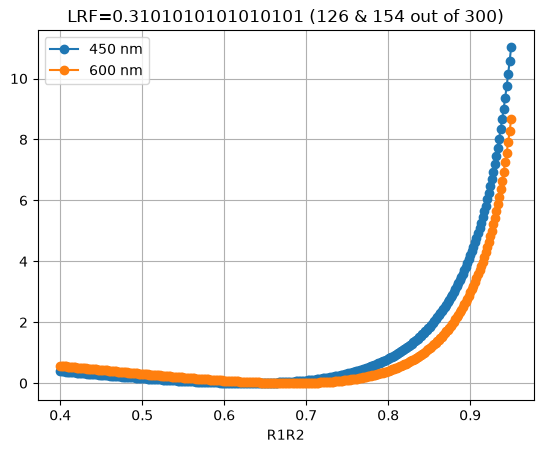

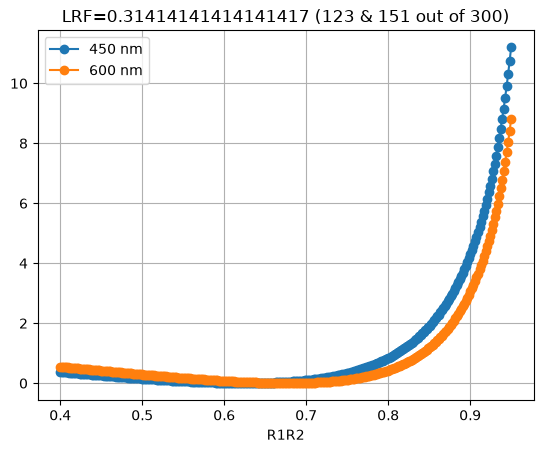

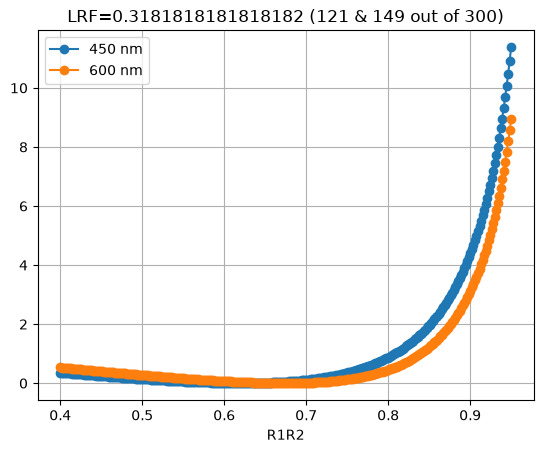

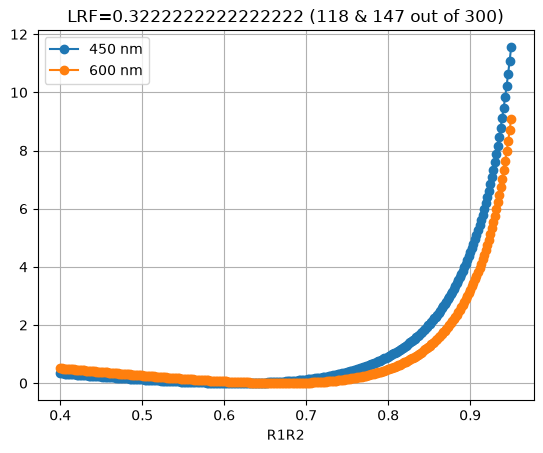

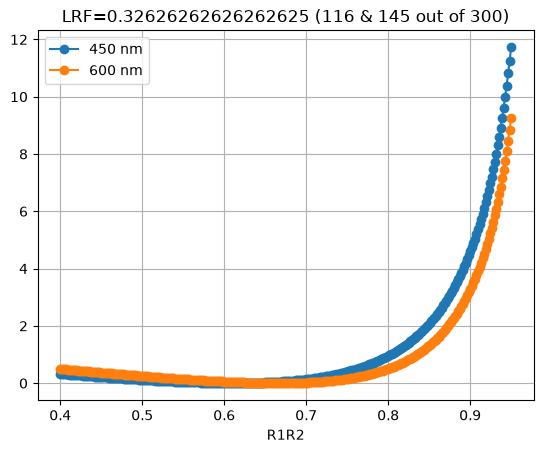

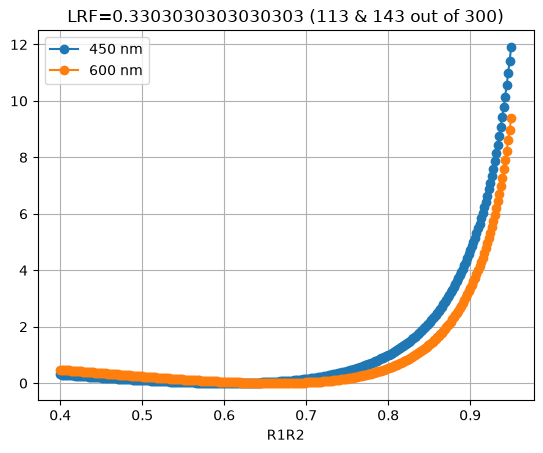

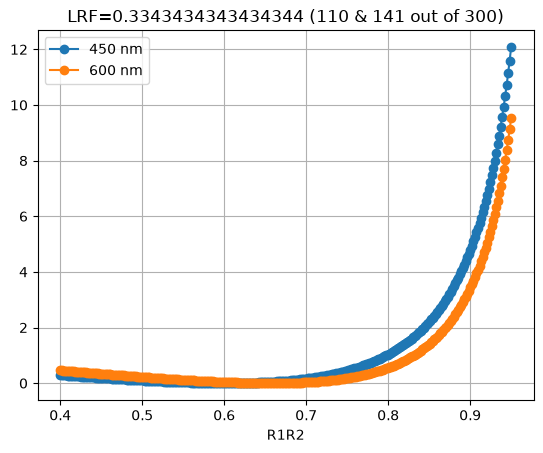

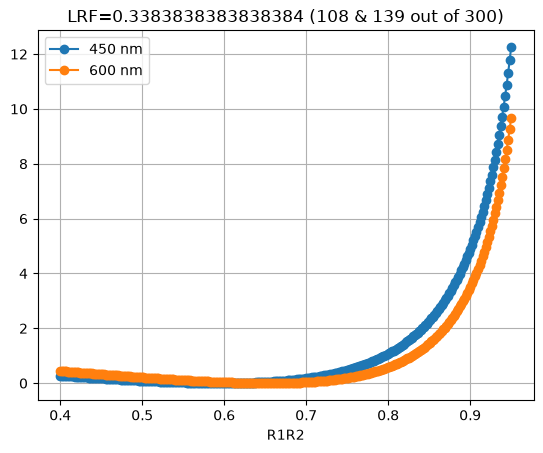

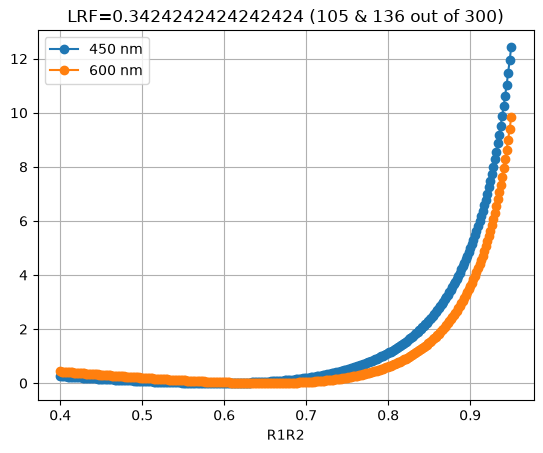

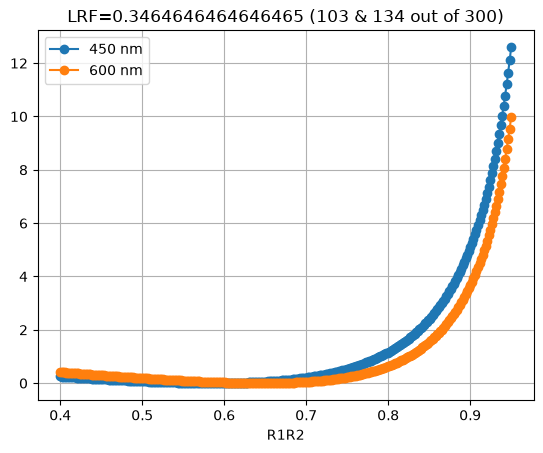

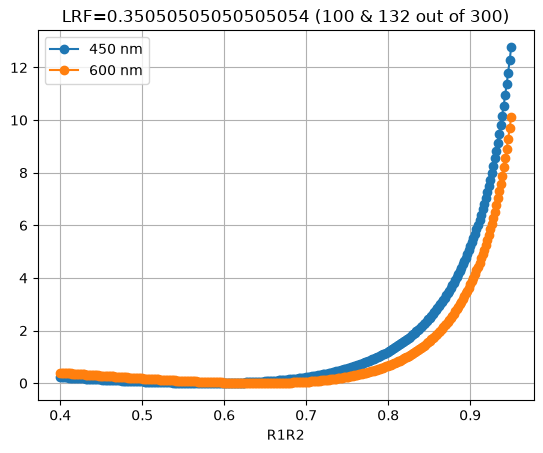

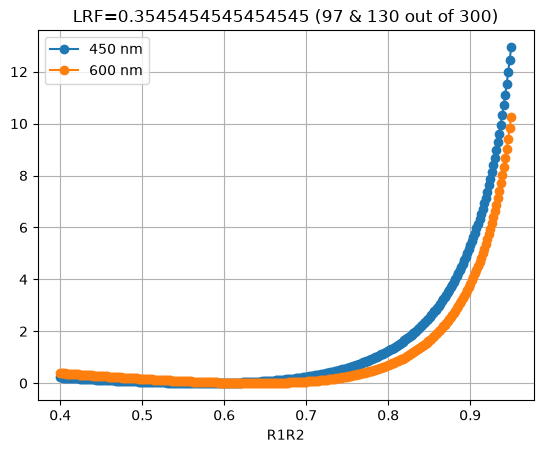

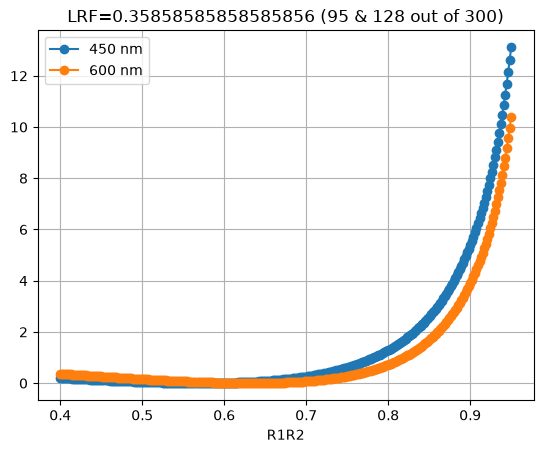

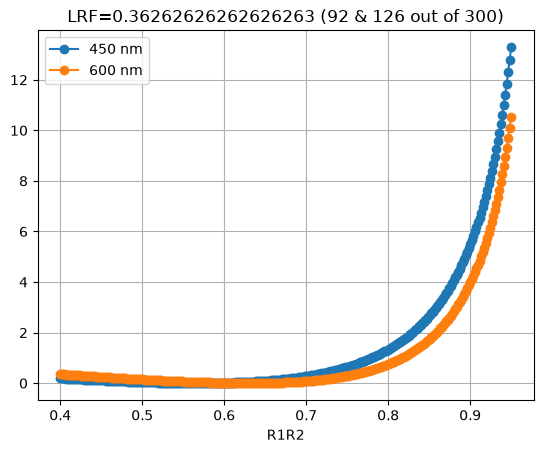

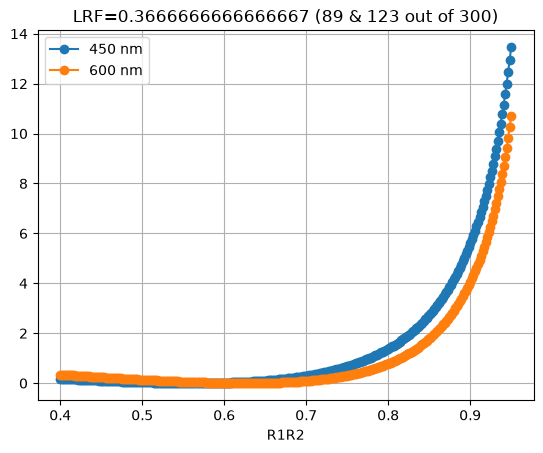

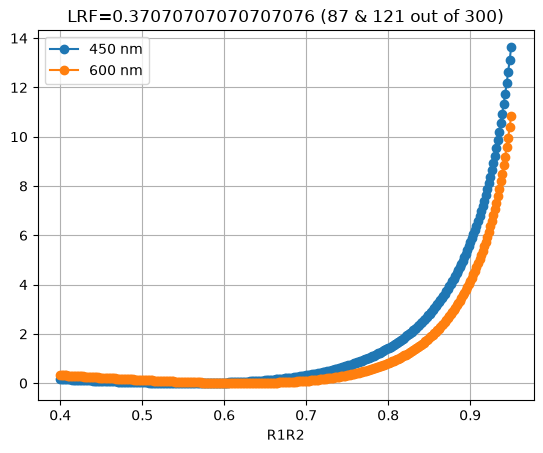

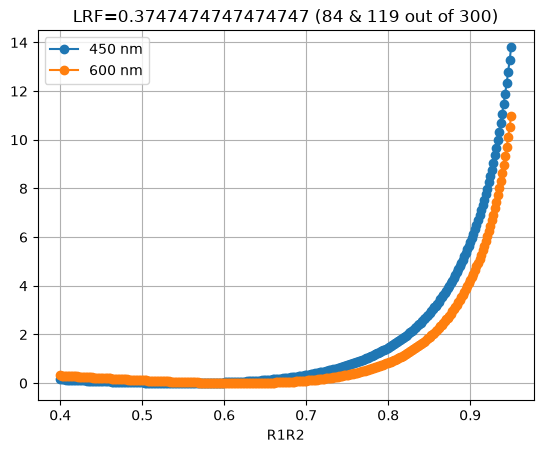

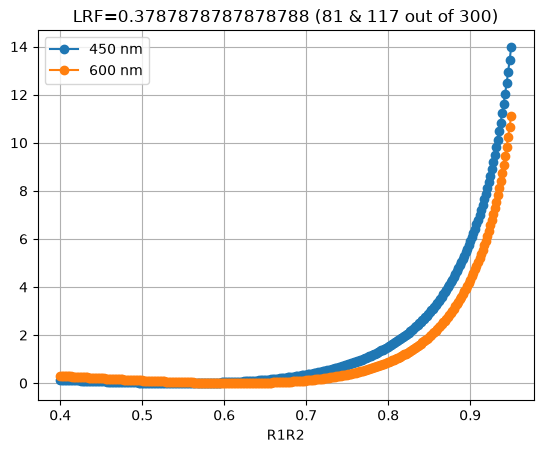

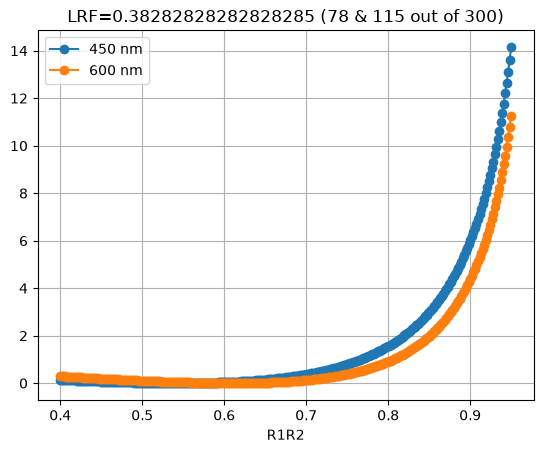

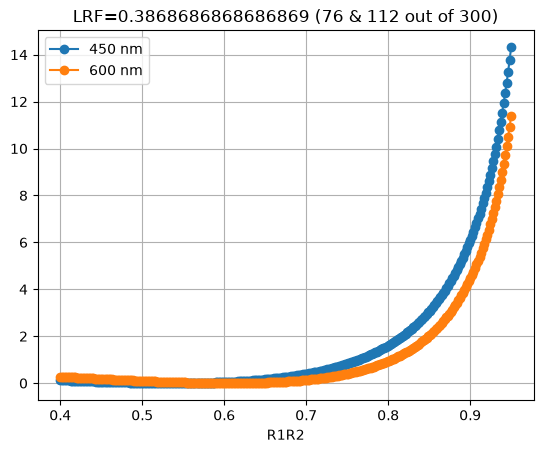

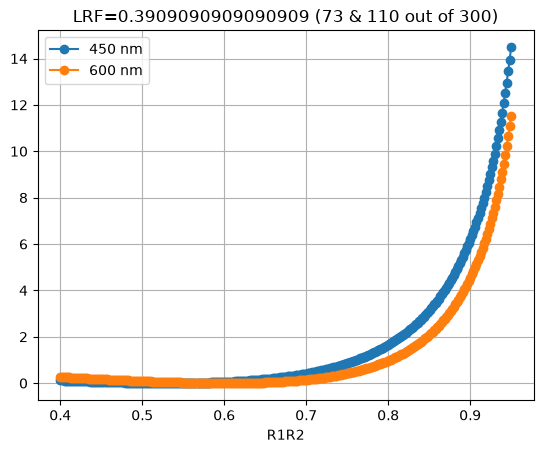

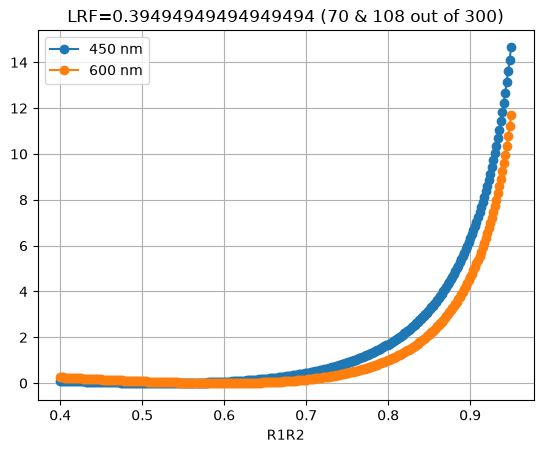

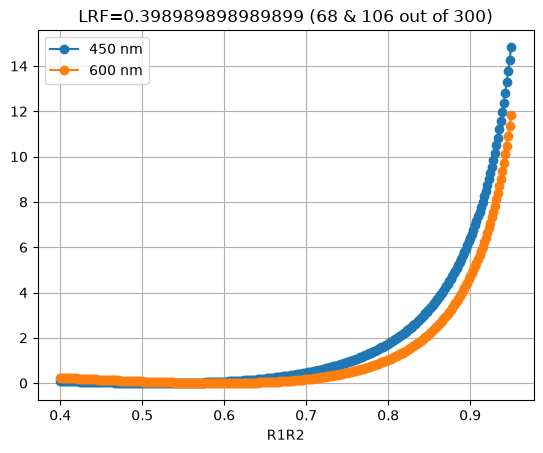

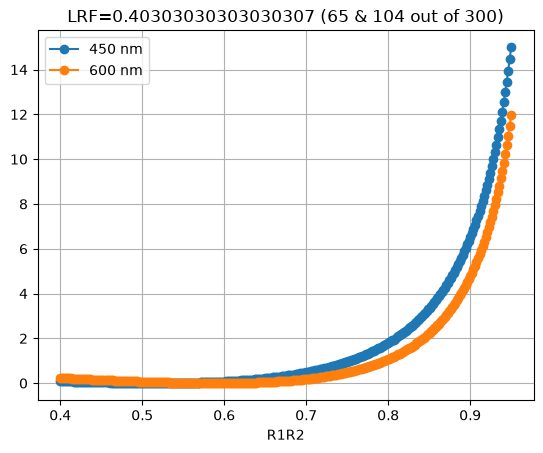

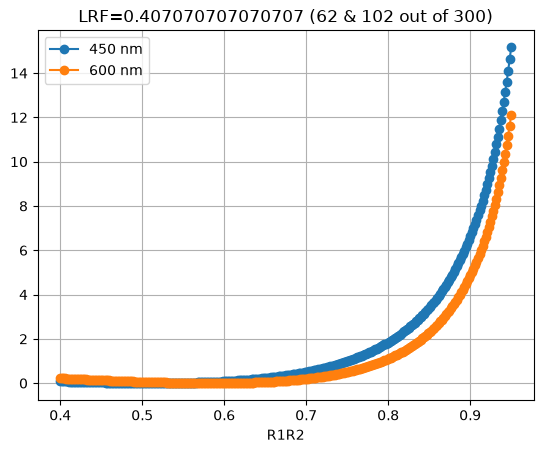

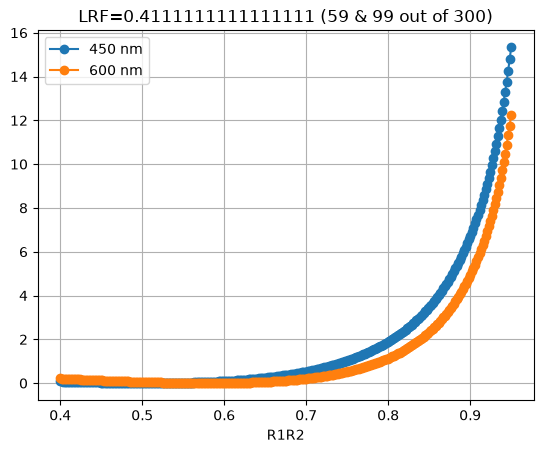

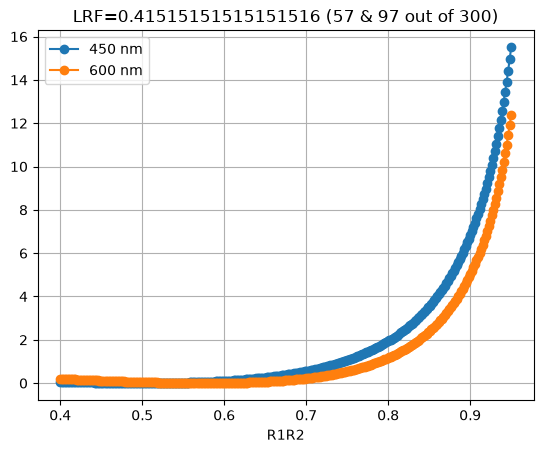

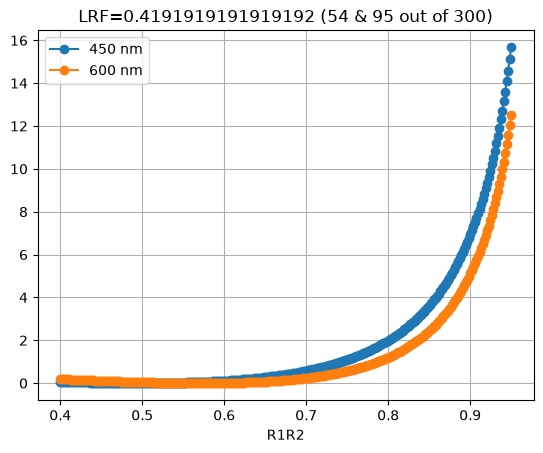

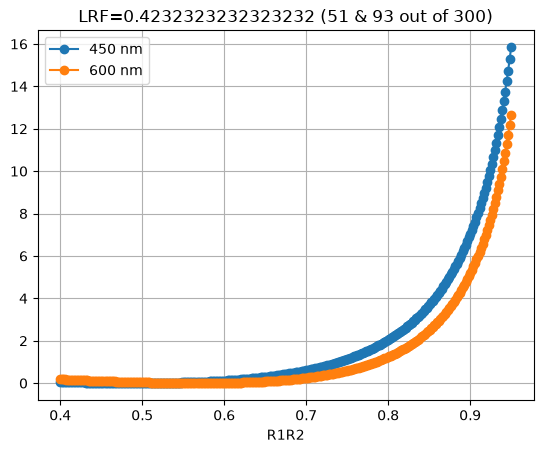

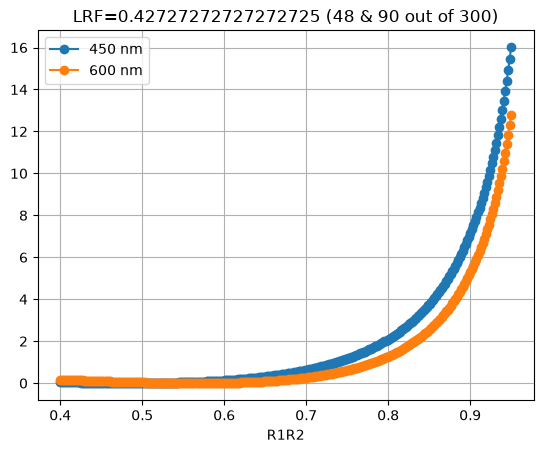

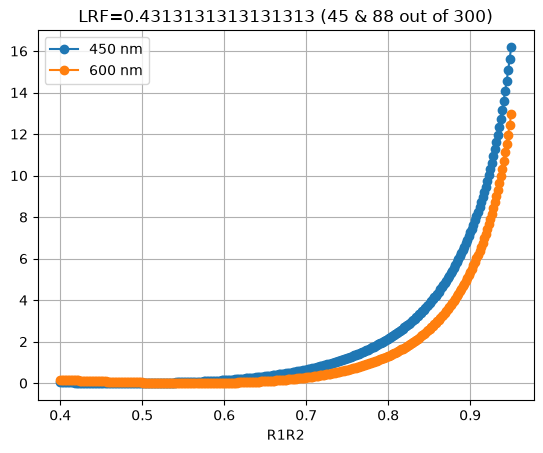

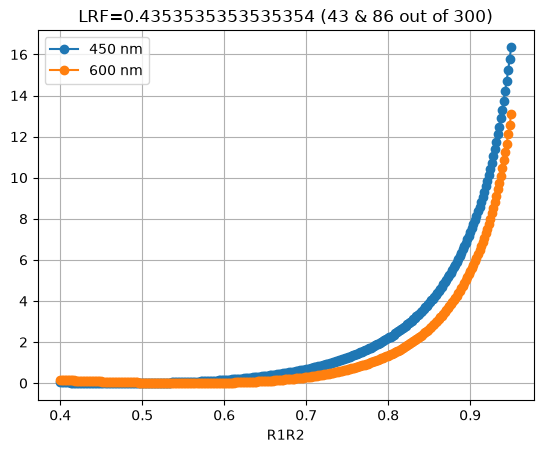

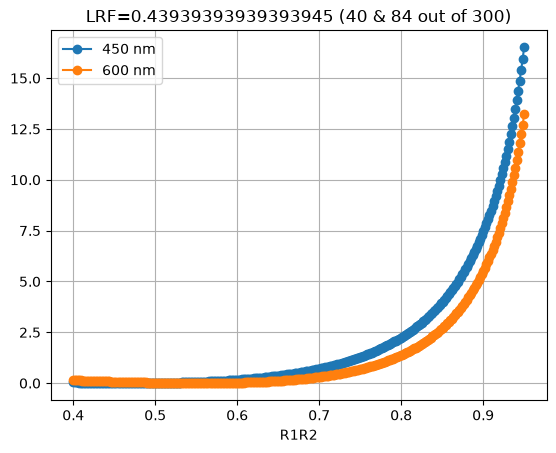

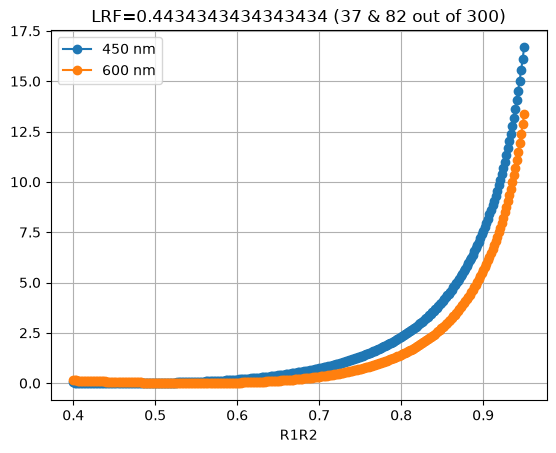

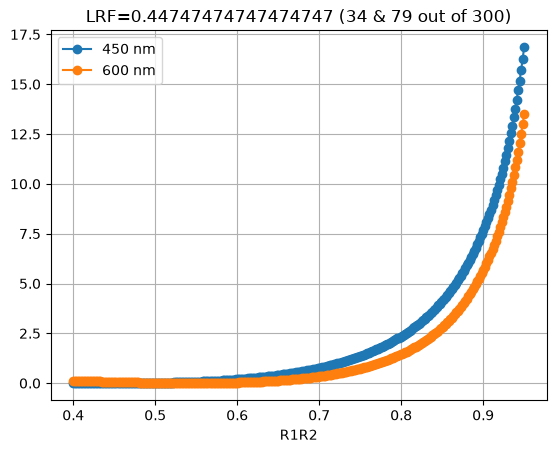

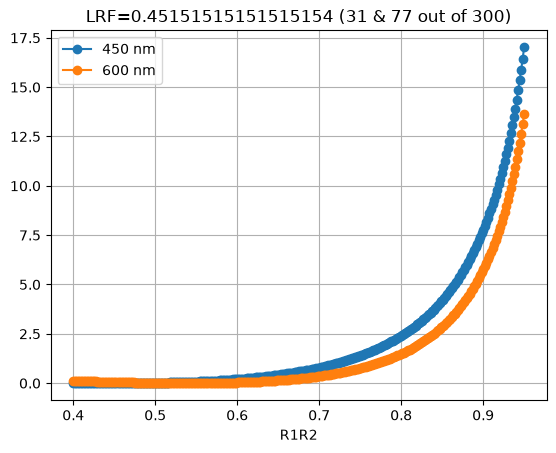

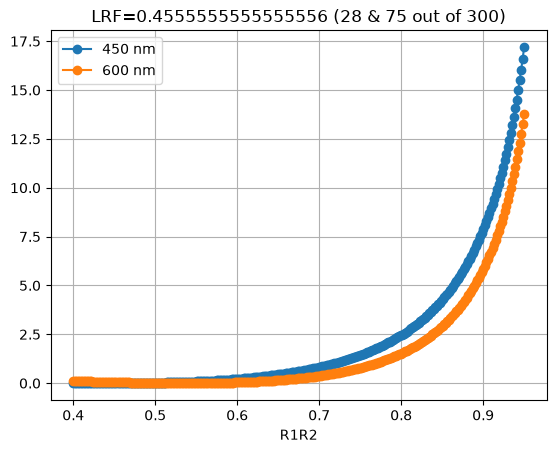

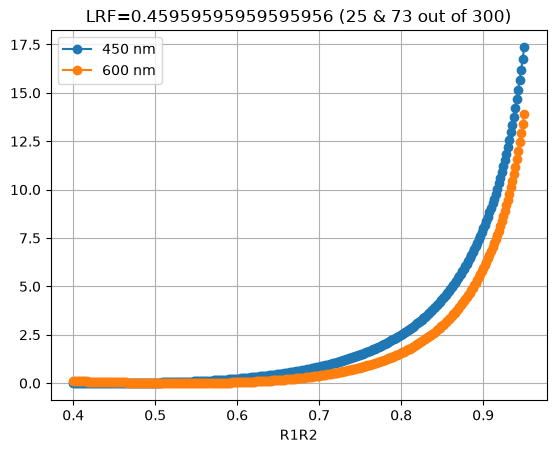

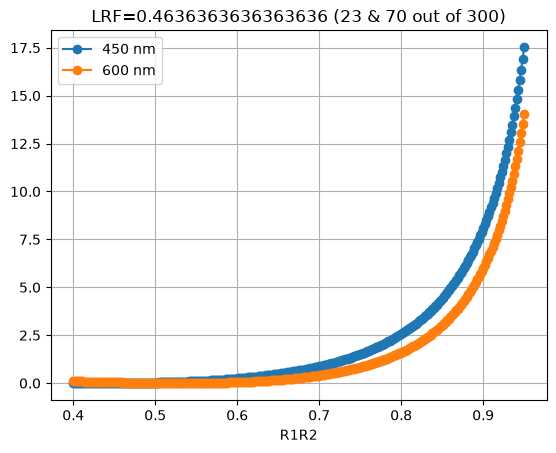

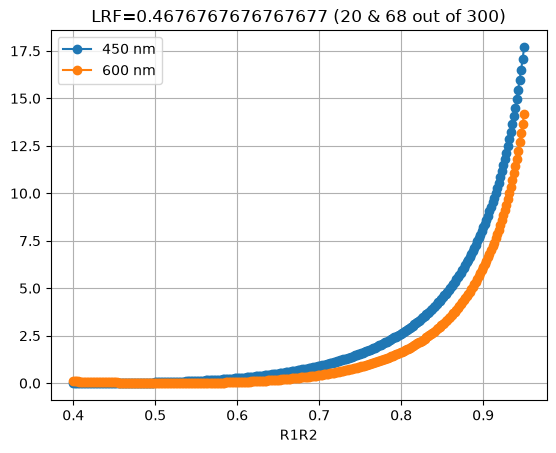

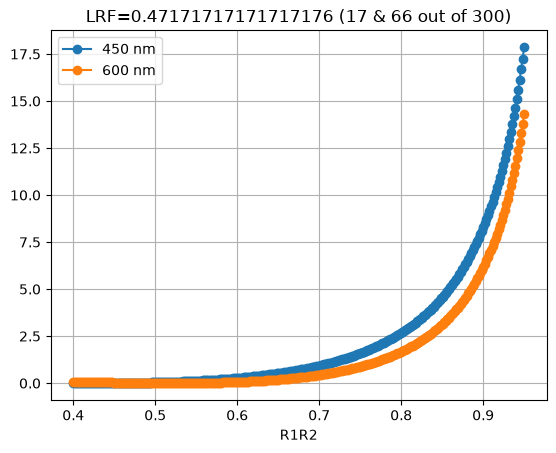

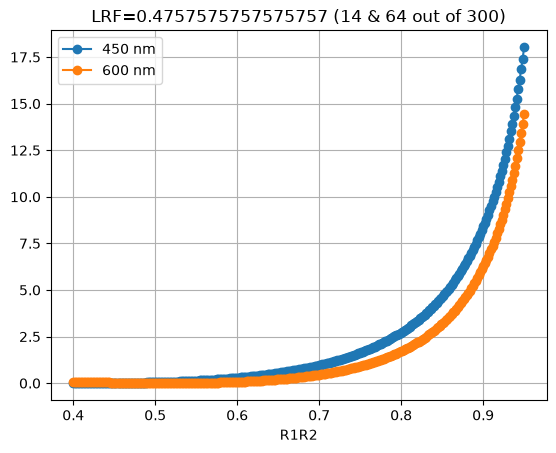

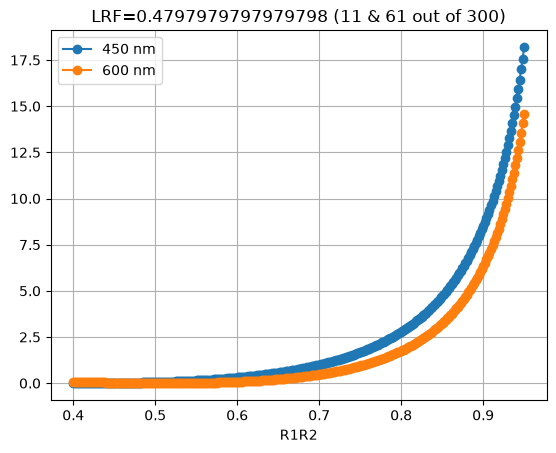

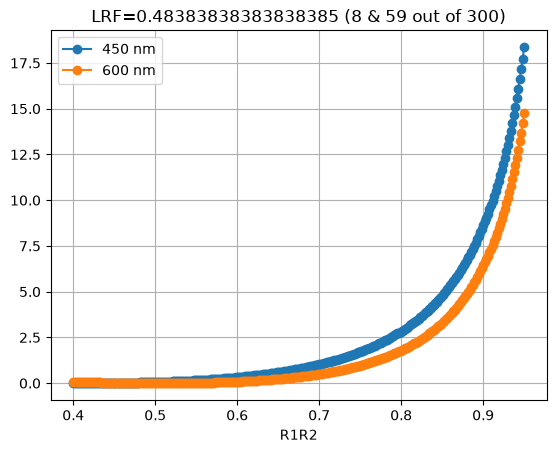

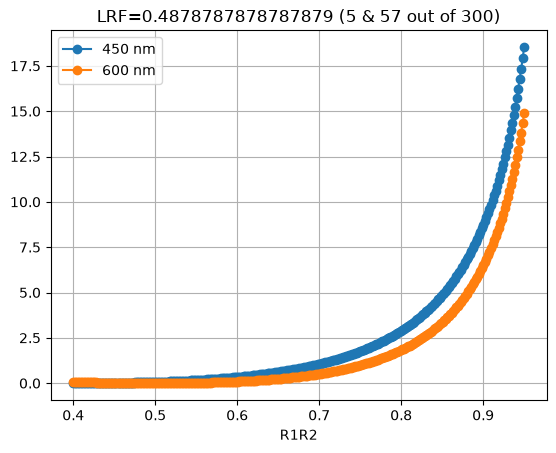

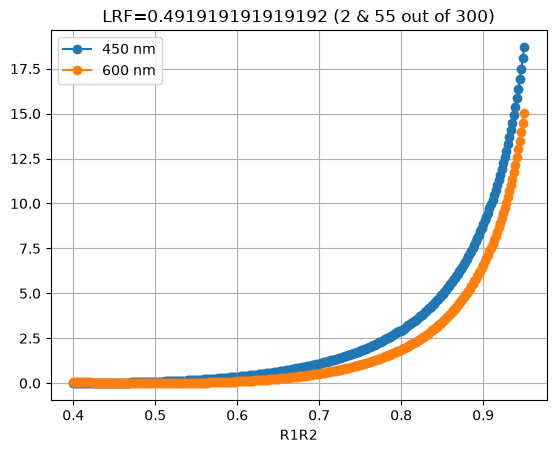

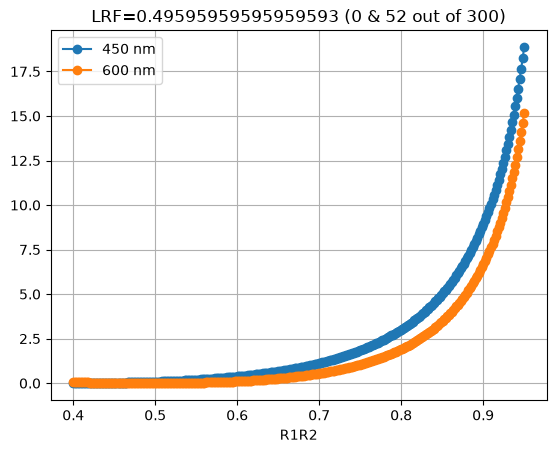

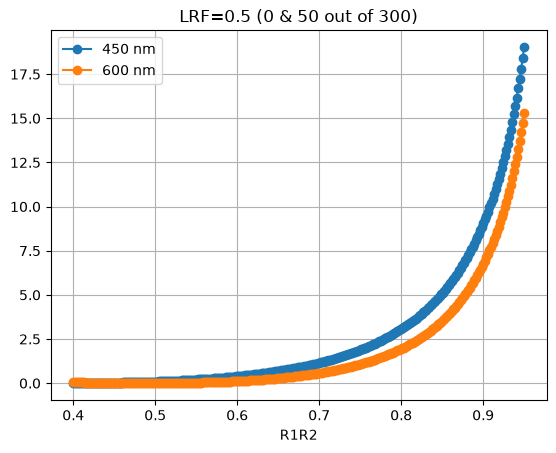

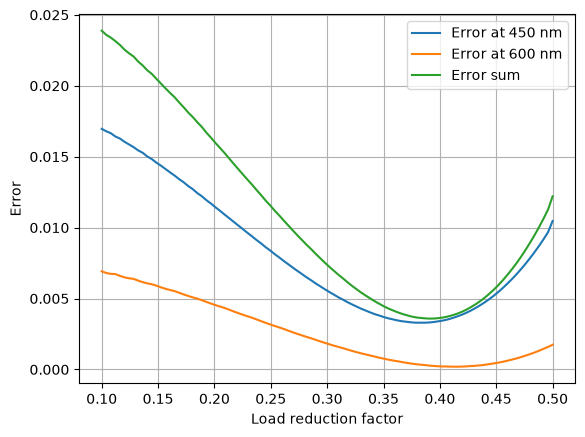

In [14]:
R1R2_1_error_range = np.zeros(np.shape(LRF_range))
R1R2_2_error_range = np.zeros(np.shape(LRF_range))

# Using Tom's theory
for iLRF in range(len(LRF_range)):
    LRF = LRF_range[iLRF]
    R1R2_1, R1R2_2, R1R2_1_error, R1R2_2_error = \
        IS.get_best_R1R2(L_range, LRF, R1R2_range, beta1_std, beta2_std, chi_observed, spectrum_list)
    R1R2_1_error_range[iLRF] = R1R2_1_error
    R1R2_2_error_range[iLRF] = R1R2_2_error

# Get the combined errors as a function of LRF
R1R2_combined_error_range = R1R2_1_error_range+R1R2_2_error_range
    
# See how we did
plt.figure()
plt.plot(LRF_range,R1R2_1_error_range,label='Error at 450 nm')
plt.plot(LRF_range,R1R2_2_error_range,label='Error at 600 nm')
plt.plot(LRF_range,R1R2_combined_error_range,label='Error sum')
plt.xlabel('Load reduction factor')
plt.ylabel('Error')
plt.legend()
plt.grid(True)

Best LRF, R1R2_1, and R1R2_2, geom. means = 0.3909090909090909 0.5342809364548495 0.6023411371237458 0.7309452349217754 0.7761063954921038


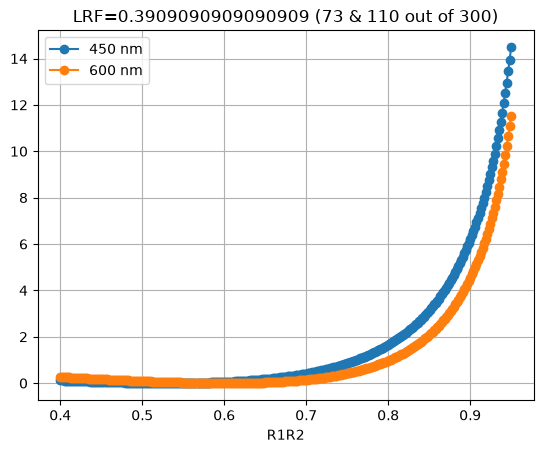

In [15]:
# Assign the best values of LRF and the R1R2s
imin_LRF = np.argmin(R1R2_combined_error_range)
LRF = LRF_range[imin_LRF]
R1R2_1, R1R2_2, R1R2_1_error, R1R2_2_error = \
        IS.get_best_R1R2(L_range, LRF, R1R2_range, beta1_std, beta2_std, chi_observed, spectrum_list)
print('Best LRF, R1R2_1, and R1R2_2, geom. means =', LRF, R1R2_1, R1R2_2, np.sqrt(R1R2_1), np.sqrt(R1R2_2))

Equivalent loadings from chi, theory values
For obs,  B.10mL.txt , L1 = 0.870177353932901 , L2 = 0.6456352954562978 , %deviation = 25.804171696924843
For obs,  A.14mL.txt , L1 = 1.1397424821243722 , L2 = 0.9174929456539741 , %deviation = 19.499978280720573
For obs,  C.20mL.txt , L1 = 3.214520296801351 , L2 = 2.987092997566984 , %deviation = 7.074999634025366
For obs,  C.34mL.txt , L1 = 6.336483236726657 , L2 = 6.282916026529796 , %deviation = 0.8453776045106852
For obs,  C.50mL.txt , L1 = 11.443228262831042 , L2 = 11.717194375189422 , %deviation = -2.3941330721178953
For obs,  C.57mL.txt , L1 = 25.462182965694975 , L2 = 25.60964391656327 , %deviation = -0.5791371111698075


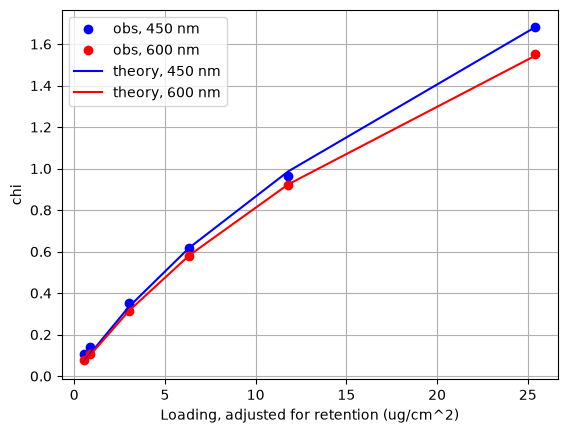

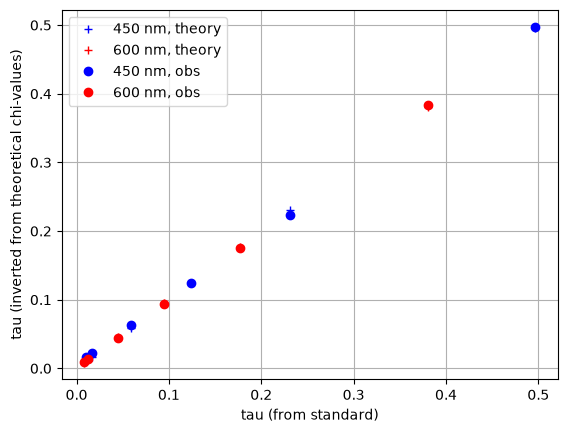

In [16]:
# Other diagnostics
chi1_obs = chi_observed[:,0]
chi2_obs = chi_observed[:,1]

tau1_range = L_range*LRF*beta1_std/100
tau2_range = L_range*LRF*beta2_std/100
chi1_theory = IS.get_chi_theory(tau1_range,R1R2_1)
chi2_theory = IS.get_chi_theory(tau2_range,R1R2_2)

plt.figure()
plt.plot(L_range,chi_observed[:,0],'o',color='blue',label='obs, 450 nm')
plt.plot(L_range,chi_observed[:,1],'o',color='red', label='obs, 600 nm')
plt.plot(L_range,chi1_theory,color='blue',label='theory, 450 nm')
plt.plot(L_range,chi2_theory,color='red',label='theory, 600 nm')
plt.legend()
plt.grid(True)
plt.xlabel('Loading, adjusted for retention (ug/cm^2)')
plt.ylabel('chi')

# Testing the inverter (theory values)
tau1_from_chi_theory = IS.invert_chi_theory(chi1_theory,R1R2=R1R2_1)
tau2_from_chi_theory = IS.invert_chi_theory(chi2_theory,R1R2=R1R2_2)
tau1_from_chi_obs = IS.invert_chi_theory(chi1_obs,R1R2=R1R2_1)
tau2_from_chi_obs = IS.invert_chi_theory(chi2_obs,R1R2=R1R2_2)

plt.figure()
plt.plot(tau1_range,tau1_from_chi_theory,'+',color='blue',label='450 nm, theory')
plt.plot(tau2_range,tau2_from_chi_theory,'+',color='red', label='600 nm, theory')
plt.plot(tau1_range,tau1_from_chi_obs,'o',color='blue',label='450 nm, obs')
plt.plot(tau2_range,tau2_from_chi_obs,'o',color='red', label='600 nm, obs')
plt.grid(True)
plt.xlabel('tau (from standard)')
plt.ylabel('tau (inverted from theoretical chi-values)')
plt.legend()
L_1list_theory = tau1_from_chi_theory/(LRF*beta1_std/100)
L_2list_theory = tau2_from_chi_theory/(LRF*beta2_std/100)
L_1list_obs = tau1_from_chi_obs/(LRF*beta1_std/100)
L_2list_obs = tau2_from_chi_obs/(LRF*beta2_std/100)
print('Equivalent loadings from chi, theory values')
for i in range(number_of_loadings):
    L1 = L_1list_theory[i]
    L2 = L_2list_theory[i]
    deviation = (L1-L2)/L1*100
    # print('For theory, ',spectrum_list[i],', L1 =', L1,', L2 =', L2, ', %deviation =', deviation)
    L1 = L_1list_obs[i]
    L2 = L_2list_obs[i]
    deviation = (L1-L2)/L1*100
    print('For obs, ',spectrum_list[i],', L1 =', L1,', L2 =', L2, ', %deviation =', deviation)

In [17]:
# Saving parameters
data = {
    "Standard": [spectrum_folder],
    "LRF": [LRF],
    "R1R2_1": [R1R2_1],
    "R1R2_2": [R1R2_2],
    "beta1_std": [beta1_std],
    "beta2_std": [beta2_std],
    "AAE_std": [AAE_std],
    "LAHM_factor": [LAHM_factor]
}
df = pd.DataFrame(data)

# Display the DataFrame
print(df)

if Save_parameter_file:
    df.to_csv(parameter_filename, index=False)

            Standard       LRF    R1R2_1    R1R2_2  beta1_std  beta2_std  \
0  UPS_INKStandards/  0.390909  0.534281  0.602341          5   3.837305   

   AAE_std  LAHM_factor  
0     0.92     0.463158  
